### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from scipy import signal
from scipy.signal import butter, filtfilt
from BaselineRemoval import BaselineRemoval

### Design Butterworth filter

In [2]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandpass')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

### Import data, remove baseline drift and filter data

#### (Our task is binary classification)

In [3]:
df = pd.DataFrame()
a = 8
useful_channel = ['F7','F3','P7','O1','O2','P8','AF4']

focus_raw = {}
unfocus_raw = {}

focus_filtered = {}
unfocus_filtered = {}

for person in range(1, 6):
    if person == 5:
        a = 7
    for day in range(1, a):
        if day == 1 or day == 2:
            continue
        if person == 4 and day == 7:
            continue

        recordname = 'eeg_record' + str(7 * (person - 1) + day)
        filename = './data/reference/original_mat/' + recordname + '.mat'
        data = scipy.io.loadmat(filename)
        data = data['o']['data'][0][0]
        eegraw = data[:20 * 128 * 60, 3:17]
        eegraw = pd.DataFrame(eegraw, columns=['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4'])
        eegraw = eegraw[useful_channel]

        focus_raw[recordname] = eegraw[:10 * 128 * 60].values.copy()
        unfocus_raw[recordname] = eegraw[10 * 128 * 60:].values.copy()

        #Initialize filtered data
        focus_filtered[recordname] = eegraw[:10 * 128 * 60].values.copy()
        unfocus_filtered[recordname] = eegraw[10 * 128 * 60:].values.copy()

        for col in range(len(useful_channel)):
            baseObj_focus = BaselineRemoval(focus_raw[recordname][:, col])
            focus_detrend = baseObj_focus.IModPoly()
            focus_filtered[recordname][:, col] = butter_bandpass_filter(focus_detrend, 0.2, 43, 128)
            # focus_filtered[recordname][:, col] = butter_bandpass_filter(focus_detrend, 0.2, 43, 128) + np.mean(focus_detrend)
            baseObj_unfocus = BaselineRemoval(unfocus_raw[recordname][:, col])
            unfocus_detrend = baseObj_unfocus.IModPoly()
            unfocus_filtered[recordname][:, col] = butter_bandpass_filter(unfocus_detrend, 0.2, 43, 128)

        print('Load ' + recordname + '.mat')


Load eeg_record3.mat
Load eeg_record4.mat
Load eeg_record5.mat
Load eeg_record6.mat
Load eeg_record7.mat
Load eeg_record10.mat
Load eeg_record11.mat
Load eeg_record12.mat
Load eeg_record13.mat
Load eeg_record14.mat
Load eeg_record17.mat
Load eeg_record18.mat
Load eeg_record19.mat
Load eeg_record20.mat
Load eeg_record21.mat
Load eeg_record24.mat
Load eeg_record25.mat
Load eeg_record26.mat
Load eeg_record27.mat
Load eeg_record31.mat
Load eeg_record32.mat
Load eeg_record33.mat
Load eeg_record34.mat


### Image about the comparison between original signal and filtered signal

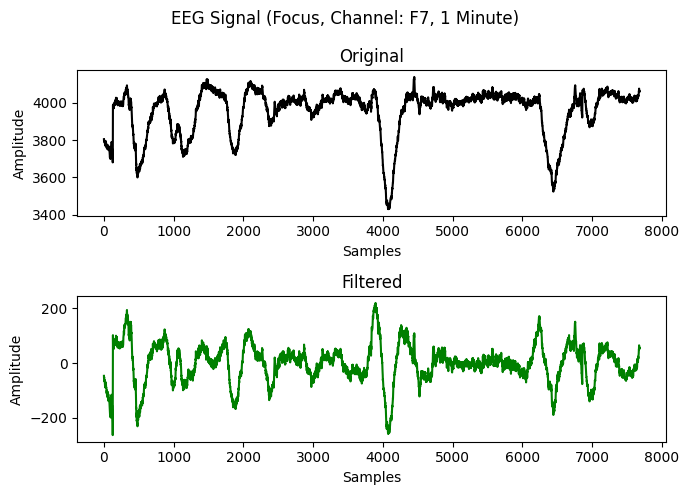

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5))
fig.suptitle('EEG Signal (Focus, Channel: F7, 1 Minute)')

ax1.plot(focus_raw['eeg_record3'][0:1 * 128 * 60, 0], color='black')
ax1.set_title('Original')
ax1.set_xlabel('Samples')
ax1.set_ylabel('Amplitude')

ax2.plot(focus_filtered['eeg_record3'][:1 * 128 * 60, 0], color='green')
ax2.set_title('Filtered')
ax2.set_xlabel('Samples')
ax2.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

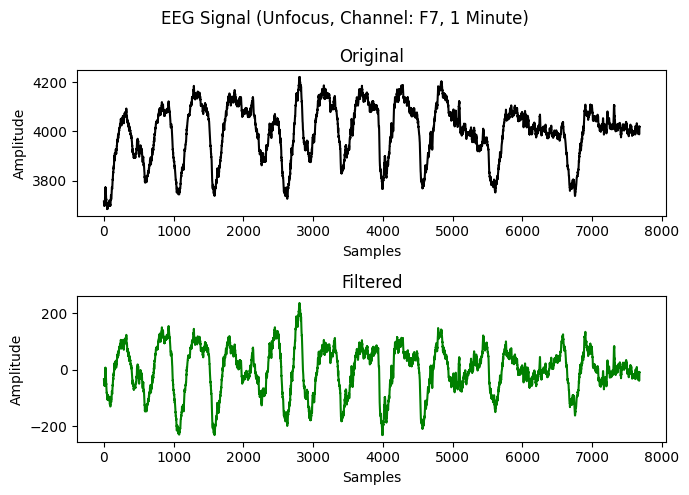

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5))
fig.suptitle('EEG Signal (Unfocus, Channel: F7, 1 Minute)')

ax1.plot(unfocus_raw['eeg_record3'][0:1 * 128 * 60, 0], color='black')
ax1.set_title('Original')
ax1.set_xlabel('Samples')
ax1.set_ylabel('Amplitude')

ax2.plot(unfocus_filtered['eeg_record3'][:1 * 128 * 60, 0], color='green')
ax2.set_title('Filtered')
ax2.set_xlabel('Samples')
ax2.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

### Apply STFT based on author's parameters settings

In [7]:
focus_power = {}
unfocus_power = {}

for recordname in focus_filtered:
    focus_power[recordname] = np.zeros([len(useful_channel), 513, 601])
    unfocus_power[recordname] = np.zeros([len(useful_channel), 513, 601])
    for channel in range(len(useful_channel)):
        f, t, Zxx1 = signal.stft(focus_filtered[recordname][:, channel], fs=128, window=signal.windows.blackman(128), nperseg=128, nfft=1024, noverlap=0)
        f, t, Zxx2 = signal.stft(unfocus_filtered[recordname][:, channel], fs=128, window=signal.windows.blackman(128), nperseg=128, nfft=1024, noverlap=0)
        focus_power[recordname][channel, :, :] = np.abs(Zxx1) ** 2
        unfocus_power[recordname][channel, :, :] = np.abs(Zxx2) ** 2

print(focus_power[recordname].shape)

(7, 513, 601)


### Image about STFT

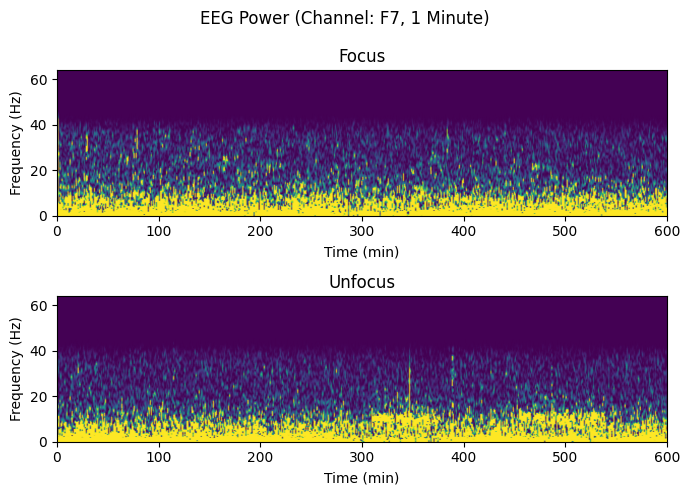

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5))
fig.suptitle('EEG Power (Channel: F7, 1 Minute)')

ax1.pcolormesh(t, f, focus_power['eeg_record3'][0, 0:1 * 128 * 60, :], vmin=0, vmax=2 * np.sqrt(2), shading='gouraud')
ax1.set_title('Focus')
ax1.set_xlabel('Time (min)')
ax1.set_ylabel('Frequency (Hz)')

ax2.pcolormesh(t, f, unfocus_power['eeg_record3'][0, 0:1 * 128 * 60, :], vmin=0, vmax=2*np.sqrt(2), shading='gouraud')
ax2.set_title('Unfocus')
ax2.set_xlabel('Time (min)')
ax2.set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

### Retains frequencies from 0 to 18Hz, binned at 0.5Hz intervals (in total 36 bins)

In [10]:
focus_power_bin = {}
unfocus_power_bin = {}

for recordname in focus_power:
    focus_power_bin[recordname] = np.zeros([len(useful_channel), 36, 601])
    unfocus_power_bin[recordname] = np.zeros([len(useful_channel), 36, 601])
    for channel in range(len(useful_channel)):
        bin_num = 0
        for i in range(1, 144, 4):
            focus_power_bin[recordname][channel, bin_num, :] = np.average(focus_power[recordname][channel, i:i+4, :], axis=0)
            unfocus_power_bin[recordname][channel, bin_num, :] = np.average(unfocus_power[recordname][channel, i:i+4, :], axis=0)
            bin_num += 1

print(focus_power_bin[recordname].shape)

(7, 36, 601)


### Apply sliding window of 15 seconds length

In [15]:
focus_power_win = {}
unfocus_power_win = {}

for recordname in focus_power:
    focus_power_win[recordname] = np.zeros([len(useful_channel), 36, 585])
    unfocus_power_win[recordname] = np.zeros([len(useful_channel), 36, 585])
    for channel in range(len(useful_channel)):
        win_num = 0
        for i in range(585):
            focus_power_win[recordname][channel, :, win_num] = np.average(focus_power_bin[recordname][channel, :, i:i+15], axis=1)
            unfocus_power_win[recordname][channel, :, win_num] = np.average(unfocus_power_bin[recordname][channel, :, i:i+15], axis=1)
            win_num += 1
print(focus_power_win[recordname].shape) 

(7, 36, 585)


### Flatten first 2 dimensions (Channels and bins)

In [17]:
focus_data = {} 
unfocus_data = {}

for recordname in focus_power_win:
    focus_data[recordname] = np.zeros([252, 585])
    unfocus_data[recordname] = np.zeros([252, 585])
    for i in range(585):
        focus_data[recordname][:, i] = focus_power_win[recordname][:, :, i].reshape(1, -1)
        unfocus_data[recordname][:, i] = unfocus_power_win[recordname][:, :, i].reshape(1, -1)
    focus_data[recordname] = 10 * np.log10(focus_data[recordname])
    unfocus_data[recordname] = 10 * np.log10(unfocus_data[recordname])
print(focus_data[recordname].shape)

(252, 585)


### Plot the image after binning and applying window

Text(0.5, 1.0, 'EEG Power (Channel: F7, 0.5 Bin)')

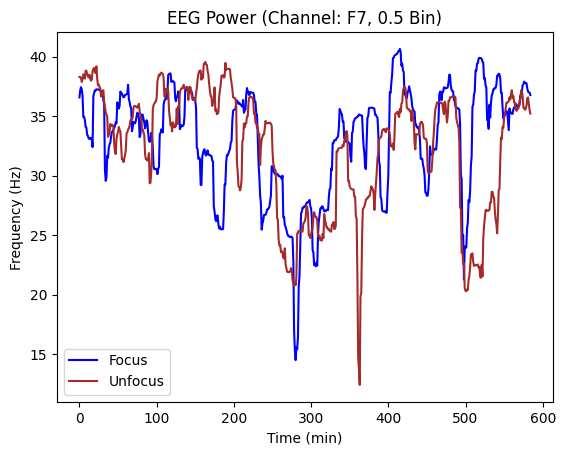

In [20]:
plt.plot(focus_data['eeg_record3'][0, :], color='blue', label='Focus')
plt.plot(unfocus_data['eeg_record3'][0, :], color='brown', label='Unfocus')
plt.legend()
plt.xlabel('Time (min)')
plt.ylabel('Frequency (Hz)')
plt.title('EEG Power (Channel: F7, 0.5 Bin)')

### Rebuild data structure, use different bins of channel data as input features

#### (We have 36 bins and 7 channels, so the size of features should be 36 * 7 = 252)

In [21]:
X = np.array([]).reshape(252, 0).copy()
y = []
for recordname in focus_data:
    X = np.concatenate((X, focus_data[recordname]), axis=1)
    X = np.concatenate((X, unfocus_data[recordname]), axis=1)
    y = y + [1] * 585 + [0] * 585

X = X.T
y = np.array(y)

### Split trainset and testset. Use 80% random data for training and the rest 20% for testing

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# I try to use the last day data of each subject for testing, but got a bad result

# test_files = ['eeg_record7', 'eeg_record14', 'eeg_record21', 'eeg_record27', 'eeg_record34']
# train_files = list(set(focus_data.keys()) - set(test_files))

# X_train = np.array([]).reshape(252, 0)
# y_train = []
# for recordname in train_files:
#     X_train = np.concatenate((X_train, focus_data[recordname]), axis=1)
#     X_train = np.concatenate((X_train, unfocus_data[recordname]), axis=1)
#     y_train = y_train + [1] * 585 + [0] * 585
# X_train = X_train.T

# X_test = np.array([]).reshape(252, 0)
# y_test = []
# for recordname in test_files:
#     X_test = np.concatenate((X_test, focus_data[recordname]), axis=1)
#     X_test = np.concatenate((X_test, unfocus_data[recordname]), axis=1)
#     y_test = y_test + [1] * 585 + [0] * 585
# X_test = X_test.T

### Import libraries and standardize data

In [24]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
# Intel® Extension for Scikit-learn is only available for Intel CPU and GPU, and is only available for Windows and Linux.
# from sklearnex import patch_sklearn, config_context
# patch_sklearn()

### Standardize data

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
np.save('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/X_train.npy', X_train)
np.save('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/X_test.npy', X_test)
np.save('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/y_train.npy', y_train)
np.save('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/y_test.npy', y_test)

X_train = np.load('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/X_train.npy')
X_test = np.load('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/X_test.npy')
y_train = np.load('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/y_train.npy')
y_test = np.load('./artifacts/reproductions/upstream_pipeline/preprocessed_arrays/y_test.npy')

### Try Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier(criterion='entropy', random_state=42)

starttime = time.time()
model_DT.fit(X_train, y_train)
endtime = time.time()
training_time_DT = endtime - starttime
print(training_time_DT)

5.242045879364014


In [28]:
y_pred_DT = model_DT.predict(X_test)
y_proba_DT = model_DT.predict_proba(X_test)[:, 1]
acc_DT = accuracy_score(y_test, y_pred_DT)
precision_DT = precision_score(y_test, y_pred_DT, pos_label=1)
recall_DT = recall_score(y_test, y_pred_DT, pos_label=1)
f1_DT = f1_score(y_test, y_pred_DT, pos_label=1)
fpr_DT, tpr_DT, _ = roc_curve(y_test, y_proba_DT)
roc_auc_DT = auc(fpr_DT, tpr_DT)

print('Accuracy:', acc_DT)

Accuracy: 0.9358974358974359


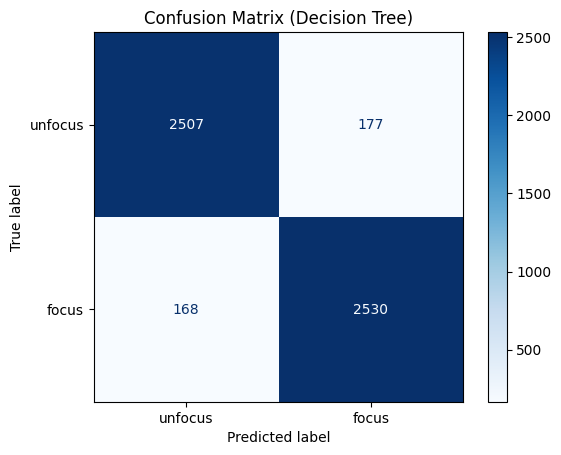

In [29]:
conf_matrix_DT = confusion_matrix(y_test, y_pred_DT)
dist = ConfusionMatrixDisplay(conf_matrix_DT, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Decision Tree)')
plt.show()

### Try Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier(criterion='entropy', random_state=42)

starttime = time.time()
model_RF.fit(X_train, y_train)
endtime = time.time()
training_time_RF = endtime - starttime

In [31]:
y_pred_RF = model_RF.predict(X_test)
y_proba_RF = model_RF.predict_proba(X_test)[:, 1]
acc_RF = accuracy_score(y_test, y_pred_RF)
precision_RF = precision_score(y_test, y_pred_RF, pos_label=1)
recall_RF = recall_score(y_test, y_pred_RF, pos_label=1)
f1_RF = f1_score(y_test, y_pred_RF, pos_label=1)
fpr_RF, tpr_RF, _ = roc_curve(y_test, y_proba_RF)
roc_auc_RF = auc(fpr_RF, tpr_RF)

print('Accuracy:', acc_RF)

Accuracy: 0.9925678186547752


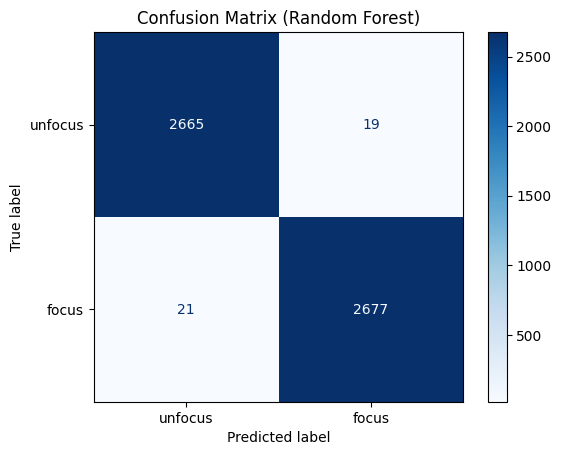

In [32]:
conf_matrix_RF = confusion_matrix(y_test, y_pred_RF)
dist = ConfusionMatrixDisplay(conf_matrix_RF, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

### Try KNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN = KNeighborsClassifier(n_neighbors=5)

starttime = time.time()
model_KNN.fit(X_train, y_train)
endtime = time.time()
training_time_KNN = endtime - starttime

In [34]:
y_pred_KNN = model_KNN.predict(X_test)
y_proba_KNN = model_KNN.predict_proba(X_test)[:, 1]
acc_KNN = accuracy_score(y_test, y_pred_KNN)
precision_KNN = precision_score(y_test, y_pred_KNN, pos_label=1)
recall_KNN = recall_score(y_test, y_pred_KNN, pos_label=1)
f1_KNN = f1_score(y_test, y_pred_KNN, pos_label=1)
fpr_KNN, tpr_KNN, _ = roc_curve(y_test, y_proba_KNN)
roc_auc_KNN = auc(fpr_KNN, tpr_KNN)

print('Accuracy:', acc_KNN)

Accuracy: 0.998513563730955


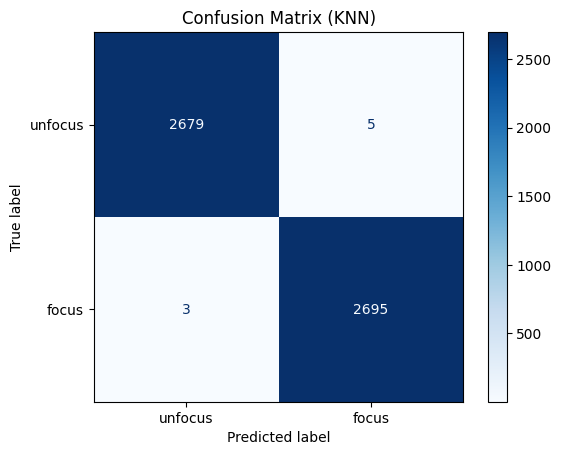

In [35]:
conf_matrix_KNN = confusion_matrix(y_test, y_pred_KNN)
dist = ConfusionMatrixDisplay(conf_matrix_KNN, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (KNN)')
plt.show()

### Try Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(max_iter=2000)

starttime = time.time()
model_LR.fit(X_train, y_train)
endtime = time.time()
training_time_LR = endtime - starttime

In [37]:
y_pred_LR = model_LR.predict(X_test)
y_proba_LR = model_LR.predict_proba(X_test)[:, 1]
acc_LR = accuracy_score(y_test, y_pred_LR)
precision_LR = precision_score(y_test, y_pred_LR, pos_label=1)
recall_LR = recall_score(y_test, y_pred_LR, pos_label=1)
f1_LR = f1_score(y_test, y_pred_LR, pos_label=1)
fpr_LR, tpr_LR, _ = roc_curve(y_test, y_proba_LR)
roc_auc_LR = auc(fpr_LR, tpr_LR)

print('Accuracy:', acc_LR)

Accuracy: 0.7978446674098848


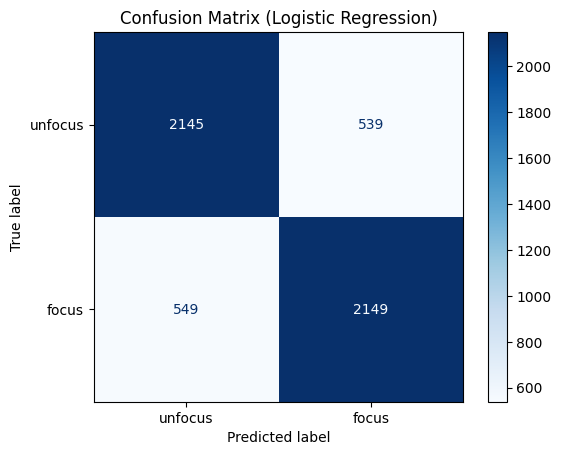

In [38]:
conf_matrix_LR = confusion_matrix(y_test, y_pred_LR)
dist = ConfusionMatrixDisplay(conf_matrix_LR, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

### Try SVM

In [39]:
from sklearn.svm import SVC

model_SVM = SVC(kernel='rbf', random_state=42, probability=True)

starttime = time.time()
model_SVM.fit(X_train, y_train)
endtime = time.time()
training_time_SVM = endtime - starttime

In [40]:
y_pred_SVM = model_SVM.predict(X_test)
y_proba_SVM = model_SVM.predict_proba(X_test)[:, 1]
acc_SVM = accuracy_score(y_test, y_pred_SVM)
precision_SVM = precision_score(y_test, y_pred_SVM, pos_label=1)
recall_SVM = recall_score(y_test, y_pred_SVM, pos_label=1)
f1_SVM = f1_score(y_test, y_pred_SVM, pos_label=1)
fpr_SVM, tpr_SVM, _ = roc_curve(y_test, y_proba_SVM)
roc_auc_SVM = auc(fpr_SVM, tpr_SVM)

print('Accuracy:', acc_SVM)

Accuracy: 0.9671125975473801


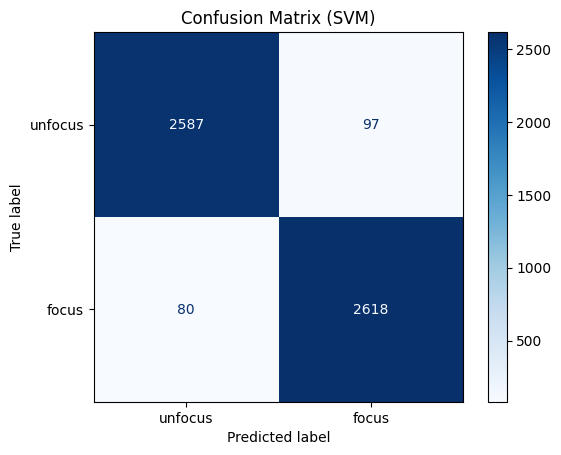

In [41]:
conf_matrix_SVM = confusion_matrix(y_test, y_pred_SVM)
dist = ConfusionMatrixDisplay(conf_matrix_SVM, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (SVM)')
plt.show()

### Deep models are now trained by isolated worker processes


In [42]:
# The original inline ResNet-18/GoogLeNet cells were moved to eeg_deep_worker.py.
# Keep running the notebook normally; after feature-reduction data is prepared,
# run_deep_workers.py will train each deep model in a fresh Python process.
print("Deep model training is deferred to isolated worker processes.")


Deep model training is deferred to isolated worker processes.


### Go back to original method, try to apply feature reduction methods

### ANOVA

In [43]:
from sklearn.feature_selection  import f_classif

F_statistic, p_values = f_classif(X_train, y_train)
selected_features = p_values < 0.05
X_train_anova = X_train[:, selected_features]
X_test_anova = X_test[:, selected_features]
X_train_anova.shape

(21528, 216)

### Feature Importance Method

In [44]:
from sklearn.ensemble import RandomForestClassifier

model_RF_temp = RandomForestClassifier(random_state=42)
model_RF_temp.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
importances = model_RF_temp.feature_importances_
selected_features = importances > np.mean(importances)
X_train_fi = X_train[:, selected_features]
X_test_fi = X_test[:, selected_features]
X_train_fi.shape

(21528, 82)

### Linear Correlation Coefficient

In [46]:
from scipy.stats import pearsonr

n_features = X_train.shape[1]
correlations = []

for i in range(n_features):
    corr, p_value = pearsonr(X_train[:, i], y_train)
    correlations.append((i, corr, p_value))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)

threshold = np.mean([abs(corr) for _, corr, _ in correlations])
selected_features = [i for i, corr, p_value in correlations if abs(corr) > threshold]

X_train_lcc = X_train[:, selected_features]
X_test_lcc = X_test[:, selected_features]
X_train_lcc.shape

(21528, 108)

### PCA

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components='mle')
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_train_pca.shape

(21528, 251)

### Save train/test arrays for isolated deep workers


In [48]:
import os

os.makedirs('./cache', exist_ok=True)

def save_deep_cache(name, Xtr, Xte):
    np.savez_compressed(
        f'./cache/{name}.npz',
        X_train=np.asarray(Xtr, dtype=np.float32),
        X_test=np.asarray(Xte, dtype=np.float32),
        y_train=np.asarray(y_train, dtype=np.int64),
        y_test=np.asarray(y_test, dtype=np.int64),
    )
    print(f'Saved ./cache/{name}.npz: train={Xtr.shape}, test={Xte.shape}')

save_deep_cache('full', X_train, X_test)
save_deep_cache('anova', X_train_anova, X_test_anova)
save_deep_cache('fi', X_train_fi, X_test_fi)
save_deep_cache('lcc', X_train_lcc, X_test_lcc)
save_deep_cache('pca', X_train_pca, X_test_pca)


Saved ./cache/full.npz: train=(21528, 252), test=(5382, 252)
Saved ./cache/anova.npz: train=(21528, 216), test=(5382, 216)
Saved ./cache/fi.npz: train=(21528, 82), test=(5382, 82)
Saved ./cache/lcc.npz: train=(21528, 108), test=(5382, 108)
Saved ./cache/pca.npz: train=(21528, 251), test=(5382, 251)


### Plot the data reduction rate

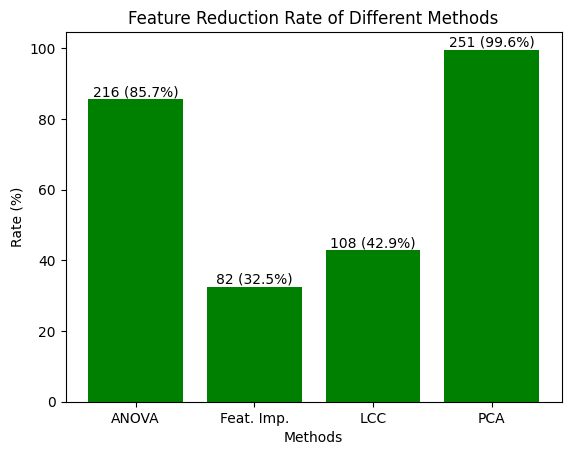

In [49]:
reduction_method = ['ANOVA', 'Feat. Imp.', 'LCC', 'PCA']
reduction_num = [X_train_anova.shape[1], X_train_fi.shape[1], X_train_lcc.shape[1], X_train_pca.shape[1]]
reduction_rate = [x / X_train.shape[1] * 100 for x in reduction_num]
labels = [f"{num} ({rate:.1f}%)" for num, rate in zip(reduction_num, reduction_rate)]
plt.bar_label(plt.bar(reduction_method, reduction_rate, color='green'), labels=labels)
plt.xlabel('Methods')
plt.ylabel('Rate (%)')
plt.title('Feature Reduction Rate of Different Methods')
plt.show()

### Also, try Decision Tree

In [50]:
model_DT_anova = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_DT_fi = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_DT_lcc = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_DT_pca = DecisionTreeClassifier(criterion='entropy', random_state=42)

starttime = time.time()
model_DT_anova.fit(X_train_anova, y_train)
endtime = time.time()
training_time_DT_anova = endtime - starttime

starttime = time.time()
model_DT_fi.fit(X_train_fi, y_train)
endtime = time.time()
training_time_DT_fi = endtime - starttime

starttime = time.time()
model_DT_lcc.fit(X_train_lcc, y_train)
endtime = time.time()
training_time_DT_lcc = endtime - starttime

starttime = time.time()
model_DT_pca.fit(X_train_pca, y_train)
endtime = time.time()
training_time_DT_pca = endtime - starttime

In [51]:
y_pred_DT_anova = model_DT_anova.predict(X_test_anova)
y_proba_DT_anova = model_DT_anova.predict_proba(X_test_anova)[:, 1]
acc_DT_anova = accuracy_score(y_test, y_pred_DT_anova)
precision_DT_anova = precision_score(y_test, y_pred_DT_anova, pos_label=1)
recall_DT_anova = recall_score(y_test, y_pred_DT_anova, pos_label=1)
f1_DT_anova = f1_score(y_test, y_pred_DT_anova, pos_label=1)
fpr_DT_anova, tpr_DT_anova, _ = roc_curve(y_test, y_proba_DT_anova)
roc_auc_DT_anova = auc(fpr_DT_anova, tpr_DT_anova)

y_pred_DT_fi = model_DT_fi.predict(X_test_fi)
y_proba_DT_fi = model_DT_fi.predict_proba(X_test_fi)[:, 1]
acc_DT_fi = accuracy_score(y_test, y_pred_DT_fi)
precision_DT_fi = precision_score(y_test, y_pred_DT_fi, pos_label=1)
recall_DT_fi = recall_score(y_test, y_pred_DT_fi, pos_label=1)
f1_DT_fi = f1_score(y_test, y_pred_DT_fi, pos_label=1)
fpr_DT_fi, tpr_DT_fi, _ = roc_curve(y_test, y_proba_DT_fi)
roc_auc_DT_fi = auc(fpr_DT_fi, tpr_DT_fi)

y_pred_DT_lcc = model_DT_lcc.predict(X_test_lcc)
y_proba_DT_lcc = model_DT_lcc.predict_proba(X_test_lcc)[:, 1]
acc_DT_lcc = accuracy_score(y_test, y_pred_DT_lcc)
precision_DT_lcc = precision_score(y_test, y_pred_DT_lcc, pos_label=1)
recall_DT_lcc = recall_score(y_test, y_pred_DT_lcc, pos_label=1)
f1_DT_lcc = f1_score(y_test, y_pred_DT_lcc, pos_label=1)
fpr_DT_lcc, tpr_DT_lcc, _ = roc_curve(y_test, y_proba_DT_lcc)
roc_auc_DT_lcc = auc(fpr_DT_lcc, tpr_DT_lcc)

y_pred_DT_pca = model_DT_pca.predict(X_test_pca)
y_proba_DT_pca = model_DT_pca.predict_proba(X_test_pca)[:, 1]
acc_DT_pca = accuracy_score(y_test, y_pred_DT_pca)
precision_DT_pca = precision_score(y_test, y_pred_DT_pca, pos_label=1)
recall_DT_pca = recall_score(y_test, y_pred_DT_pca, pos_label=1)
f1_DT_pca = f1_score(y_test, y_pred_DT_pca, pos_label=1)
fpr_DT_pca, tpr_DT_pca, _ = roc_curve(y_test, y_proba_DT_pca)
roc_auc_DT_pca = auc(fpr_DT_pca, tpr_DT_pca)

print('Accuracy(ANOVA):', acc_DT_anova)
print('Accuracy(Feature Importance):', acc_DT_fi)
print('Accuracy(Linear Correlation Coefficient):', acc_DT_lcc)
print('Accuracy(PCA):', acc_DT_pca)

Accuracy(ANOVA): 0.9360832404310665
Accuracy(Feature Importance): 0.9364548494983278
Accuracy(Linear Correlation Coefficient): 0.9251207729468599
Accuracy(PCA): 0.8827573392790784


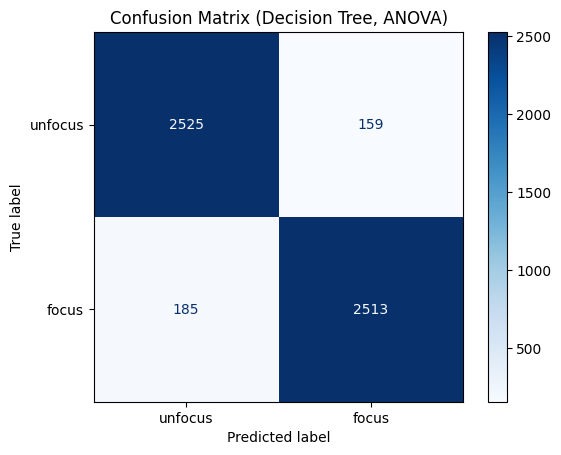

In [52]:
conf_matrix_DT_anova = confusion_matrix(y_test, y_pred_DT_anova)
dist = ConfusionMatrixDisplay(conf_matrix_DT_anova, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Decision Tree, ANOVA)')
plt.show()

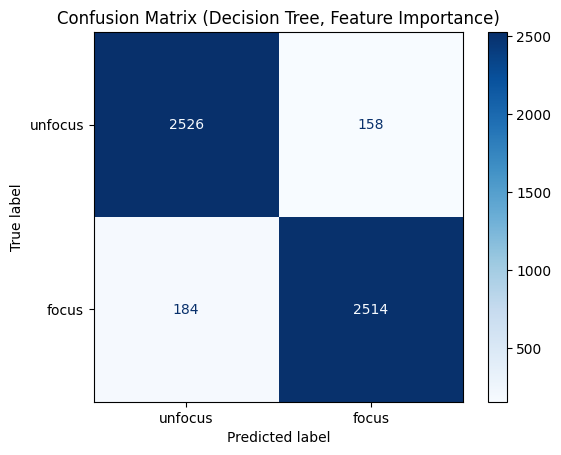

In [53]:
conf_matrix_DT_fi = confusion_matrix(y_test, y_pred_DT_fi)
dist = ConfusionMatrixDisplay(conf_matrix_DT_fi, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Decision Tree, Feature Importance)')
plt.show()

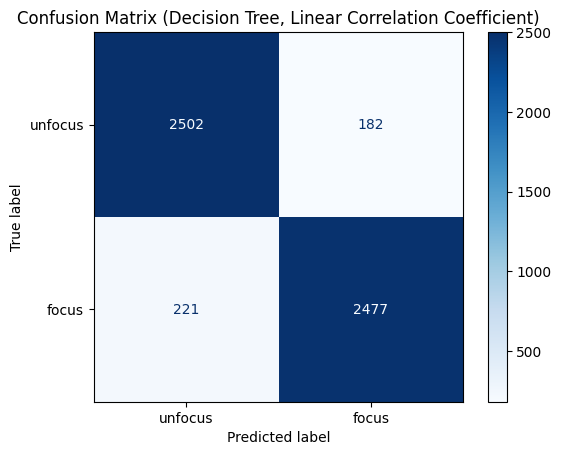

In [54]:
conf_matrix_DT_lcc = confusion_matrix(y_test, y_pred_DT_lcc)
dist = ConfusionMatrixDisplay(conf_matrix_DT_lcc, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Decision Tree, Linear Correlation Coefficient)')
plt.show()

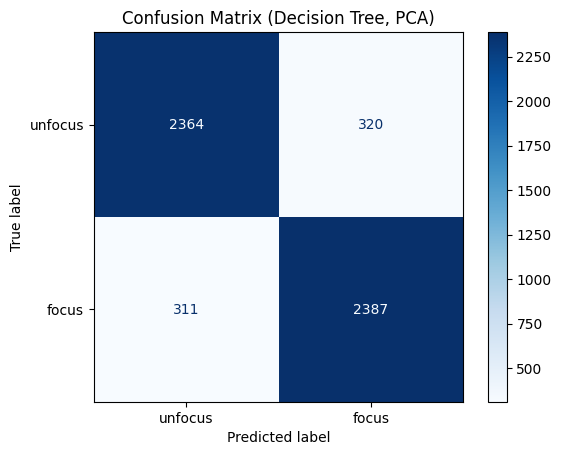

In [55]:
conf_matrix_DT_pca = confusion_matrix(y_test, y_pred_DT_pca)
dist = ConfusionMatrixDisplay(conf_matrix_DT_pca, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Decision Tree, PCA)')
plt.show()

### Try Random Forest

In [56]:
model_RF_anova = RandomForestClassifier(criterion='entropy', random_state=42)
model_RF_fi = RandomForestClassifier(criterion='entropy', random_state=42)
model_RF_lcc = RandomForestClassifier(criterion='entropy', random_state=42)
model_RF_pca = RandomForestClassifier(criterion='entropy', random_state=42)

starttime = time.time()
model_RF_anova.fit(X_train_anova, y_train)
endtime = time.time()
training_time_RF_anova = endtime - starttime

starttime = time.time()
model_RF_fi.fit(X_train_fi, y_train)
endtime = time.time()
training_time_RF_fi = endtime - starttime

starttime = time.time()
model_RF_lcc.fit(X_train_lcc, y_train)
endtime = time.time()
training_time_RF_lcc = endtime - starttime

starttime = time.time()
model_RF_pca.fit(X_train_pca, y_train)
endtime = time.time()
training_time_RF_pca = endtime - starttime

In [57]:
y_pred_RF_anova = model_RF_anova.predict(X_test_anova)
y_proba_RF_anova = model_RF_anova.predict_proba(X_test_anova)[:, 1]
acc_RF_anova = accuracy_score(y_test, y_pred_RF_anova)
precision_RF_anova = precision_score(y_test, y_pred_RF_anova, pos_label=1)
recall_RF_anova = recall_score(y_test, y_pred_RF_anova, pos_label=1)
f1_RF_anova = f1_score(y_test, y_pred_RF_anova, pos_label=1)
fpr_RF_anova, tpr_RF_anova, _ = roc_curve(y_test, y_proba_RF_anova)
roc_auc_RF_anova = auc(fpr_RF_anova, tpr_RF_anova)

y_pred_RF_fi = model_RF_fi.predict(X_test_fi)
y_proba_RF_fi = model_RF_fi.predict_proba(X_test_fi)[:, 1]
acc_RF_fi = accuracy_score(y_test, y_pred_RF_fi)
precision_RF_fi = precision_score(y_test, y_pred_RF_fi, pos_label=1)
recall_RF_fi = recall_score(y_test, y_pred_RF_fi, pos_label=1)
f1_RF_fi = f1_score(y_test, y_pred_RF_fi, pos_label=1)
fpr_RF_fi, tpr_RF_fi, _ = roc_curve(y_test, y_proba_RF_fi)
roc_auc_RF_fi = auc(fpr_RF_fi, tpr_RF_fi)

y_pred_RF_lcc = model_RF_lcc.predict(X_test_lcc)
y_proba_RF_lcc = model_RF_lcc.predict_proba(X_test_lcc)[:, 1]
acc_RF_lcc = accuracy_score(y_test, y_pred_RF_lcc)
precision_RF_lcc = precision_score(y_test, y_pred_RF_lcc, pos_label=1)
recall_RF_lcc = recall_score(y_test, y_pred_RF_lcc, pos_label=1)
f1_RF_lcc = f1_score(y_test, y_pred_RF_lcc, pos_label=1)
fpr_RF_lcc, tpr_RF_lcc, _ = roc_curve(y_test, y_proba_RF_lcc)
roc_auc_RF_lcc = auc(fpr_RF_lcc, tpr_RF_lcc)

y_pred_RF_pca = model_RF_pca.predict(X_test_pca)
y_proba_RF_pca = model_RF_pca.predict_proba(X_test_pca)[:, 1]
acc_RF_pca = accuracy_score(y_test, y_pred_RF_pca)
precision_RF_pca = precision_score(y_test, y_pred_RF_pca, pos_label=1)
recall_RF_pca = recall_score(y_test, y_pred_RF_pca, pos_label=1)
f1_RF_pca = f1_score(y_test, y_pred_RF_pca, pos_label=1)
fpr_RF_pca, tpr_RF_pca, _ = roc_curve(y_test, y_proba_RF_pca)
roc_auc_RF_pca = auc(fpr_RF_pca, tpr_RF_pca)

print('Accuracy(ANOVA):', acc_RF_anova)
print('Accuracy(Feature Importance):', acc_RF_fi)
print('Accuracy(Linear Correlation Coefficient):', acc_RF_lcc)
print('Accuracy(PCA):', acc_RF_pca)

Accuracy(ANOVA): 0.9925678186547752
Accuracy(Feature Importance): 0.9881085098476403
Accuracy(Linear Correlation Coefficient): 0.9873652917131178
Accuracy(PCA): 0.9875510962467484


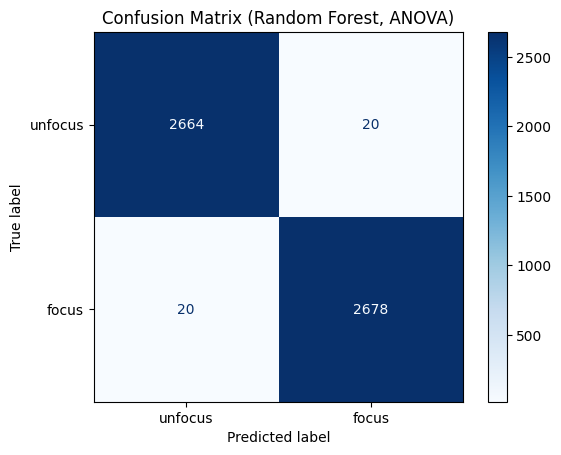

In [58]:
conf_matrix_RF_anova = confusion_matrix(y_test, y_pred_RF_anova)
dist = ConfusionMatrixDisplay(conf_matrix_RF_anova, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Random Forest, ANOVA)')
plt.show()

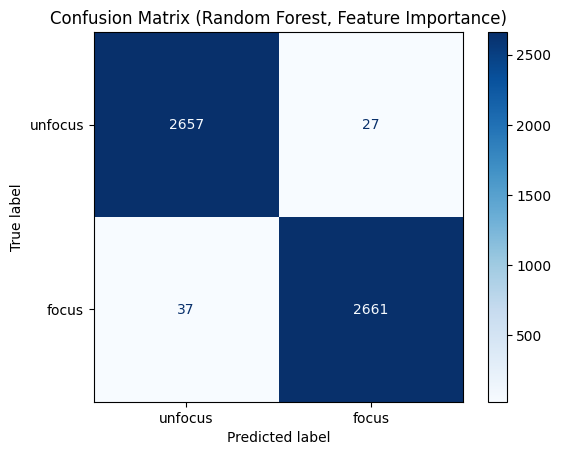

In [59]:
conf_matrix_RF_fi = confusion_matrix(y_test, y_pred_RF_fi)
dist = ConfusionMatrixDisplay(conf_matrix_RF_fi, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Random Forest, Feature Importance)')
plt.show()

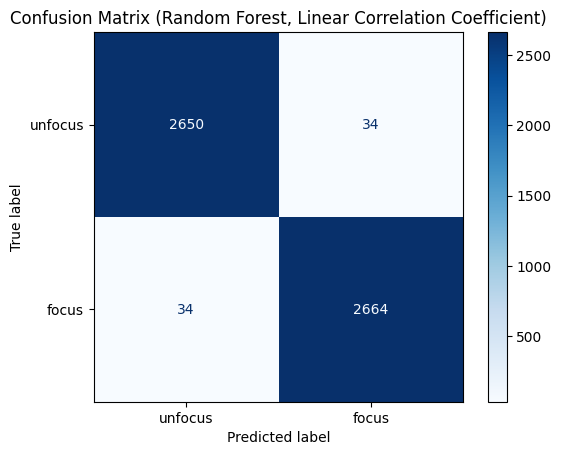

In [60]:
conf_matrix_RF_lcc = confusion_matrix(y_test, y_pred_RF_lcc)
dist = ConfusionMatrixDisplay(conf_matrix_RF_lcc, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Random Forest, Linear Correlation Coefficient)')
plt.show()

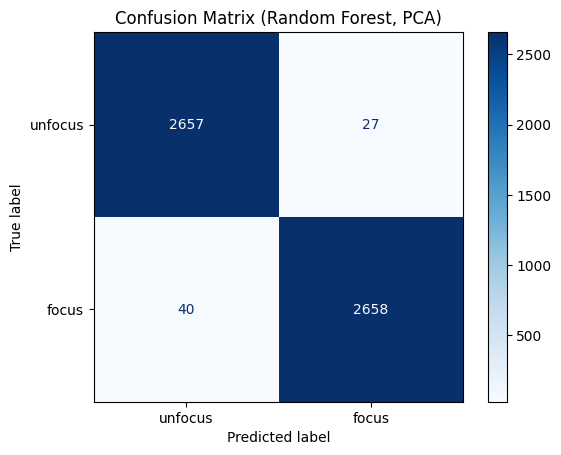

In [61]:
conf_matrix_RF_pca = confusion_matrix(y_test, y_pred_RF_pca)
dist = ConfusionMatrixDisplay(conf_matrix_RF_pca, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Random Forest, PCA)')
plt.show()

### Try KNN

In [62]:
model_KNN_anova = KNeighborsClassifier(n_neighbors=5)
model_KNN_fi = KNeighborsClassifier(n_neighbors=5)
model_KNN_lcc = KNeighborsClassifier(n_neighbors=5)
model_KNN_pca = KNeighborsClassifier(n_neighbors=5)

starttime = time.time()
model_KNN_anova.fit(X_train_anova, y_train)
endtime = time.time()
training_time_KNN_anova = endtime - starttime

starttime = time.time()
model_KNN_fi.fit(X_train_fi, y_train)
endtime = time.time()
training_time_KNN_fi = endtime - starttime

starttime = time.time()
model_KNN_lcc.fit(X_train_lcc, y_train)
endtime = time.time()
training_time_KNN_lcc = endtime - starttime

starttime = time.time()
model_KNN_pca.fit(X_train_pca, y_train)
endtime = time.time()
training_time_KNN_pca = endtime - starttime

In [63]:
y_pred_KNN_anova = model_KNN_anova.predict(X_test_anova)
y_proba_KNN_anova = model_KNN_anova.predict_proba(X_test_anova)[:, 1]
acc_KNN_anova = accuracy_score(y_test, y_pred_KNN_anova)
precision_KNN_anova = precision_score(y_test, y_pred_KNN_anova, pos_label=1)
recall_KNN_anova = recall_score(y_test, y_pred_KNN_anova, pos_label=1)
f1_KNN_anova = f1_score(y_test, y_pred_KNN_anova, pos_label=1)
fpr_KNN_anova, tpr_KNN_anova, _ = roc_curve(y_test, y_proba_KNN_anova)
roc_auc_KNN_anova = auc(fpr_KNN_anova, tpr_KNN_anova)

y_pred_KNN_fi = model_KNN_fi.predict(X_test_fi)
y_proba_KNN_fi = model_KNN_fi.predict_proba(X_test_fi)[:, 1]
acc_KNN_fi = accuracy_score(y_test, y_pred_KNN_fi)
precision_KNN_fi = precision_score(y_test, y_pred_KNN_fi, pos_label=1)
recall_KNN_fi = recall_score(y_test, y_pred_KNN_fi, pos_label=1)
f1_KNN_fi = f1_score(y_test, y_pred_KNN_fi, pos_label=1)
fpr_KNN_fi, tpr_KNN_fi, _ = roc_curve(y_test, y_proba_KNN_fi)
roc_auc_KNN_fi = auc(fpr_KNN_fi, tpr_KNN_fi)

y_pred_KNN_lcc = model_KNN_lcc.predict(X_test_lcc)
y_proba_KNN_lcc = model_KNN_lcc.predict_proba(X_test_lcc)[:, 1]
acc_KNN_lcc = accuracy_score(y_test, y_pred_KNN_lcc)
precision_KNN_lcc = precision_score(y_test, y_pred_KNN_lcc, pos_label=1)
recall_KNN_lcc = recall_score(y_test, y_pred_KNN_lcc, pos_label=1)
f1_KNN_lcc = f1_score(y_test, y_pred_KNN_lcc, pos_label=1)
fpr_KNN_lcc, tpr_KNN_lcc, _ = roc_curve(y_test, y_proba_KNN_lcc)
roc_auc_KNN_lcc = auc(fpr_KNN_lcc, tpr_KNN_lcc)

y_pred_KNN_pca = model_KNN_pca.predict(X_test_pca)
y_proba_KNN_pca = model_KNN_pca.predict_proba(X_test_pca)[:, 1]
acc_KNN_pca = accuracy_score(y_test, y_pred_KNN_pca)
precision_KNN_pca = precision_score(y_test, y_pred_KNN_pca, pos_label=1)
recall_KNN_pca = recall_score(y_test, y_pred_KNN_pca, pos_label=1)
f1_KNN_pca = f1_score(y_test, y_pred_KNN_pca, pos_label=1)
fpr_KNN_pca, tpr_KNN_pca, _ = roc_curve(y_test, y_proba_KNN_pca)
roc_auc_KNN_pca = auc(fpr_KNN_pca, tpr_KNN_pca)

print('Accuracy(ANOVA):', acc_KNN_anova)
print('Accuracy(Feature Importance):', acc_KNN_fi)
print('Accuracy(Linear Correlation Coefficient):', acc_KNN_lcc)
print('Accuracy(PCA):', acc_KNN_pca)

Accuracy(ANOVA): 0.9977703455964325
Accuracy(Feature Importance): 0.9959123002601263
Accuracy(Linear Correlation Coefficient): 0.9957264957264957
Accuracy(PCA): 0.998513563730955


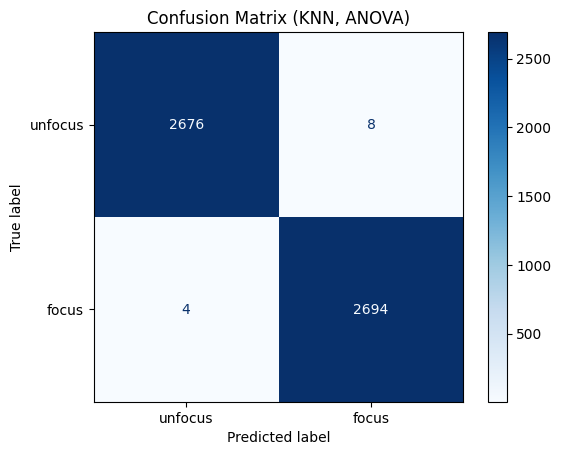

In [64]:
conf_matrix_KNN_anova = confusion_matrix(y_test, y_pred_KNN_anova)
dist = ConfusionMatrixDisplay(conf_matrix_KNN_anova, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (KNN, ANOVA)')
plt.show()

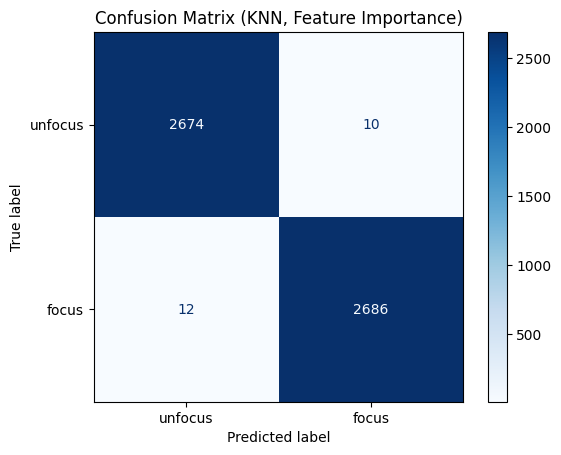

In [65]:
conf_matrix_KNN_fi = confusion_matrix(y_test, y_pred_KNN_fi)
dist = ConfusionMatrixDisplay(conf_matrix_KNN_fi, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (KNN, Feature Importance)')
plt.show()

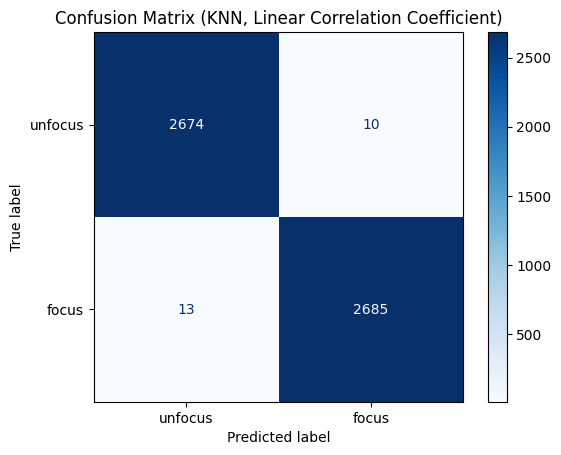

In [66]:
conf_matrix_KNN_lcc = confusion_matrix(y_test, y_pred_KNN_lcc)
dist = ConfusionMatrixDisplay(conf_matrix_KNN_lcc, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (KNN, Linear Correlation Coefficient)')
plt.show()

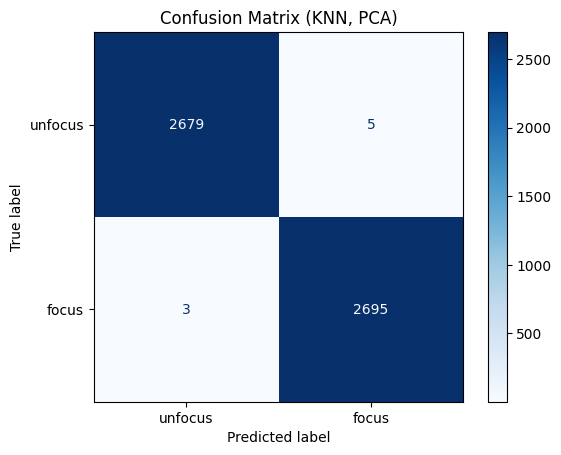

In [67]:
conf_matrix_KNN_pca = confusion_matrix(y_test, y_pred_KNN_pca)
dist = ConfusionMatrixDisplay(conf_matrix_KNN_pca, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (KNN, PCA)')
plt.show()

### Try Logisitc Regression

In [68]:
model_LR_anova = LogisticRegression(max_iter=2000)
model_LR_fi = LogisticRegression(max_iter=2000)
model_LR_lcc = LogisticRegression(max_iter=2000)
model_LR_pca = LogisticRegression(max_iter=2000)

starttime = time.time()
model_LR_anova.fit(X_train_anova, y_train)
endtime = time.time()
training_time_LR_anova = endtime - starttime

starttime = time.time()
model_LR_fi.fit(X_train_fi, y_train)
endtime = time.time()
training_time_LR_fi = endtime - starttime

starttime = time.time()
model_LR_lcc.fit(X_train_lcc, y_train)
endtime = time.time()
training_time_LR_lcc = endtime - starttime

starttime = time.time()
model_LR_pca.fit(X_train_pca, y_train)
endtime = time.time()
training_time_LR_pca = endtime - starttime

In [69]:
y_pred_LR_anova = model_LR_anova.predict(X_test_anova)
y_proba_LR_anova = model_LR_anova.predict_proba(X_test_anova)[:, 1]
acc_LR_anova = accuracy_score(y_test, y_pred_LR_anova)
precision_LR_anova = precision_score(y_test, y_pred_LR_anova, pos_label=1)
recall_LR_anova = recall_score(y_test, y_pred_LR_anova, pos_label=1)
f1_LR_anova = f1_score(y_test, y_pred_LR_anova, pos_label=1)
fpr_LR_anova, tpr_LR_anova, _ = roc_curve(y_test, y_proba_LR_anova)
roc_auc_LR_anova = auc(fpr_LR_anova, tpr_LR_anova)

y_pred_LR_fi = model_LR_fi.predict(X_test_fi)
y_proba_LR_fi = model_LR_fi.predict_proba(X_test_fi)[:, 1]
acc_LR_fi = accuracy_score(y_test, y_pred_LR_fi)
precision_LR_fi = precision_score(y_test, y_pred_LR_fi, pos_label=1)
recall_LR_fi = recall_score(y_test, y_pred_LR_fi, pos_label=1)
f1_LR_fi = f1_score(y_test, y_pred_LR_fi, pos_label=1)
fpr_LR_fi, tpr_LR_fi, _ = roc_curve(y_test, y_proba_LR_fi)
roc_auc_LR_fi = auc(fpr_LR_fi, tpr_LR_fi)

y_pred_LR_lcc = model_LR_lcc.predict(X_test_lcc)
y_proba_LR_lcc = model_LR_lcc.predict_proba(X_test_lcc)[:, 1]
acc_LR_lcc = accuracy_score(y_test, y_pred_LR_lcc)
precision_LR_lcc = precision_score(y_test, y_pred_LR_lcc, pos_label=1)
recall_LR_lcc = recall_score(y_test, y_pred_LR_lcc, pos_label=1)
f1_LR_lcc = f1_score(y_test, y_pred_LR_lcc, pos_label=1)
fpr_LR_lcc, tpr_LR_lcc, _ = roc_curve(y_test, y_proba_LR_lcc)
roc_auc_LR_lcc = auc(fpr_LR_lcc, tpr_LR_lcc)

y_pred_LR_pca = model_LR_pca.predict(X_test_pca)
y_proba_LR_pca = model_LR_pca.predict_proba(X_test_pca)[:, 1]
acc_LR_pca = accuracy_score(y_test, y_pred_LR_pca)
precision_LR_pca = precision_score(y_test, y_pred_LR_pca, pos_label=1)
recall_LR_pca = recall_score(y_test, y_pred_LR_pca, pos_label=1)
f1_LR_pca = f1_score(y_test, y_pred_LR_pca, pos_label=1)
fpr_LR_pca, tpr_LR_pca, _ = roc_curve(y_test, y_proba_LR_pca)
roc_auc_LR_pca = auc(fpr_LR_pca, tpr_LR_pca)

print('Accuracy(ANOVA):', acc_LR_anova)
print('Accuracy(Feature Importance):', acc_LR_fi)
print('Accuracy(Linear Correlation Coefficient):', acc_LR_lcc)
print('Accuracy(PCA):', acc_LR_pca)

Accuracy(ANOVA): 0.7971014492753623
Accuracy(Feature Importance): 0.7753623188405797
Accuracy(Linear Correlation Coefficient): 0.7716462281679674
Accuracy(PCA): 0.798216276477146


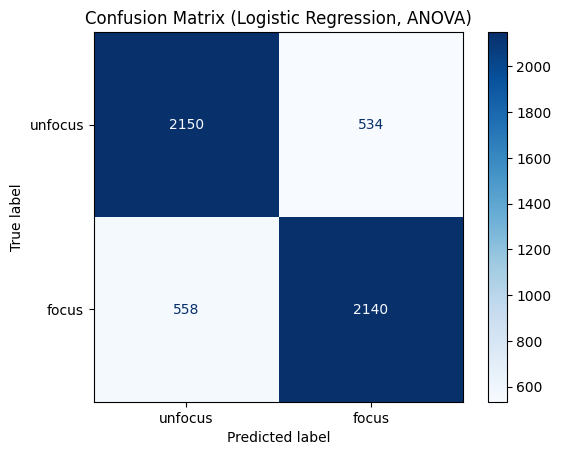

In [70]:
conf_matrix_LR_anova = confusion_matrix(y_test, y_pred_LR_anova)
dist = ConfusionMatrixDisplay(conf_matrix_LR_anova, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression, ANOVA)')
plt.show()

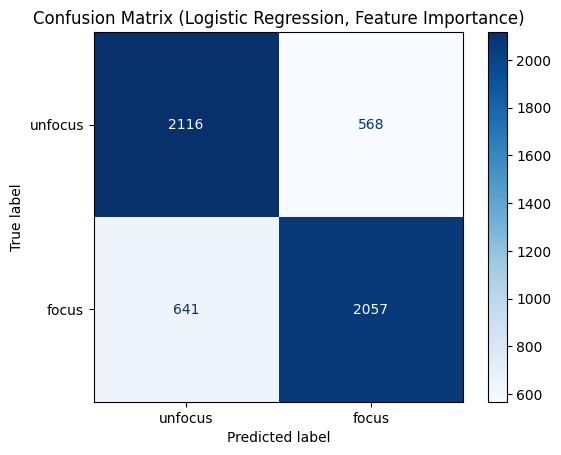

In [71]:
conf_matrix_LR_fi = confusion_matrix(y_test, y_pred_LR_fi)
dist = ConfusionMatrixDisplay(conf_matrix_LR_fi, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression, Feature Importance)')
plt.show()

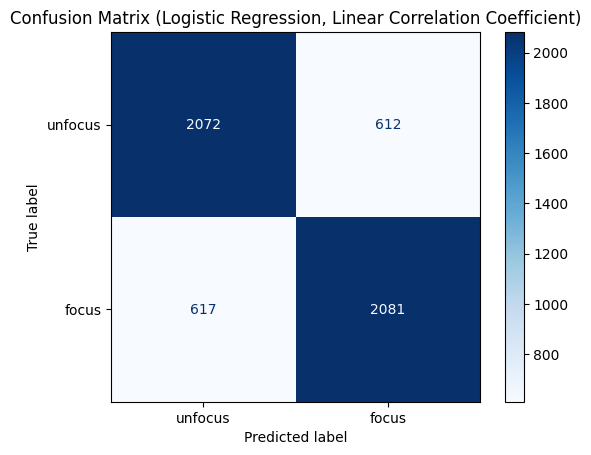

In [72]:
conf_matrix_LR_lcc = confusion_matrix(y_test, y_pred_LR_lcc)
dist = ConfusionMatrixDisplay(conf_matrix_LR_lcc, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression, Linear Correlation Coefficient)')
plt.show()

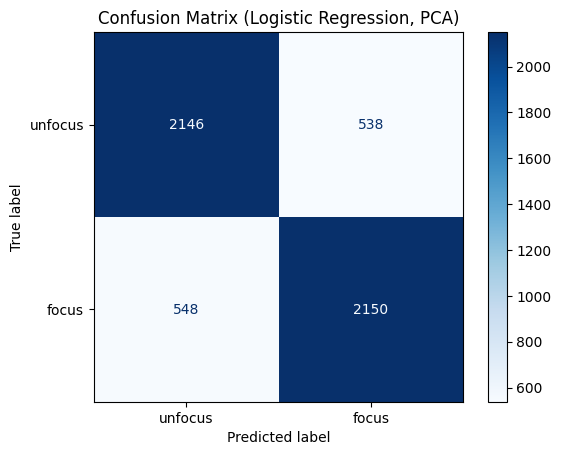

In [73]:
conf_matrix_LR_pca = confusion_matrix(y_test, y_pred_LR_pca)
dist = ConfusionMatrixDisplay(conf_matrix_LR_pca, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression, PCA)')
plt.show()

### Try SVM

In [74]:
model_SVM_anova = SVC(kernel='rbf', random_state=42, probability=True)
model_SVM_fi = SVC(kernel='rbf', random_state=42, probability=True)
model_SVM_lcc = SVC(kernel='rbf', random_state=42, probability=True)
model_SVM_pca = SVC(kernel='rbf', random_state=42, probability=True)

starttime = time.time()
model_SVM_anova.fit(X_train_anova, y_train)
endtime = time.time()
training_time_SVM_anova = endtime - starttime

starttime = time.time()
model_SVM_fi.fit(X_train_fi, y_train)
endtime = time.time()
training_time_SVM_fi = endtime - starttime

starttime = time.time()
model_SVM_lcc.fit(X_train_lcc, y_train)
endtime = time.time()
training_time_SVM_lcc = endtime - starttime

starttime = time.time()
model_SVM_pca.fit(X_train_pca, y_train)
endtime = time.time()
training_time_SVM_pca = endtime - starttime

In [75]:
y_pred_SVM_anova = model_SVM_anova.predict(X_test_anova)
y_proba_SVM_anova = model_SVM_anova.predict_proba(X_test_anova)[:, 1]
acc_SVM_anova = accuracy_score(y_test, y_pred_SVM_anova)
precision_SVM_anova = precision_score(y_test, y_pred_SVM_anova, pos_label=1)
recall_SVM_anova = recall_score(y_test, y_pred_SVM_anova, pos_label=1)
f1_SVM_anova = f1_score(y_test, y_pred_SVM_anova, pos_label=1)
fpr_SVM_anova, tpr_SVM_anova, _ = roc_curve(y_test, y_proba_SVM_anova)
roc_auc_SVM_anova = auc(fpr_SVM_anova, tpr_SVM_anova)

y_pred_SVM_fi = model_SVM_fi.predict(X_test_fi)
y_proba_SVM_fi = model_SVM_fi.predict_proba(X_test_fi)[:, 1]
acc_SVM_fi = accuracy_score(y_test, y_pred_SVM_fi)
precision_SVM_fi = precision_score(y_test, y_pred_SVM_fi, pos_label=1)
recall_SVM_fi = recall_score(y_test, y_pred_SVM_fi, pos_label=1)
f1_SVM_fi = f1_score(y_test, y_pred_SVM_fi, pos_label=1)
fpr_SVM_fi, tpr_SVM_fi, _ = roc_curve(y_test, y_proba_SVM_fi)
roc_auc_SVM_fi = auc(fpr_SVM_fi, tpr_SVM_fi)

y_pred_SVM_lcc = model_SVM_lcc.predict(X_test_lcc)
y_proba_SVM_lcc = model_SVM_lcc.predict_proba(X_test_lcc)[:, 1]
acc_SVM_lcc = accuracy_score(y_test, y_pred_SVM_lcc)
precision_SVM_lcc = precision_score(y_test, y_pred_SVM_lcc, pos_label=1)
recall_SVM_lcc = recall_score(y_test, y_pred_SVM_lcc, pos_label=1)
f1_SVM_lcc = f1_score(y_test, y_pred_SVM_lcc, pos_label=1)
fpr_SVM_lcc, tpr_SVM_lcc, _ = roc_curve(y_test, y_proba_SVM_lcc)
roc_auc_SVM_lcc = auc(fpr_SVM_lcc, tpr_SVM_lcc)

y_pred_SVM_pca = model_SVM_pca.predict(X_test_pca)
y_proba_SVM_pca = model_SVM_pca.predict_proba(X_test_pca)[:, 1]
acc_SVM_pca = accuracy_score(y_test, y_pred_SVM_pca)
precision_SVM_pca = precision_score(y_test, y_pred_SVM_pca, pos_label=1)
recall_SVM_pca = recall_score(y_test, y_pred_SVM_pca, pos_label=1)
f1_SVM_pca = f1_score(y_test, y_pred_SVM_pca, pos_label=1)
fpr_SVM_pca, tpr_SVM_pca, _ = roc_curve(y_test, y_proba_SVM_pca)
roc_auc_SVM_pca = auc(fpr_SVM_pca, tpr_SVM_pca)

print('Accuracy(ANOVA):', acc_SVM_anova)
print('Accuracy(Feature Importance):', acc_SVM_fi)
print('Accuracy(Linear Correlation Coefficient):', acc_SVM_lcc)
print('Accuracy(PCA):', acc_SVM_pca)

Accuracy(ANOVA): 0.9630248978075066
Accuracy(Feature Importance): 0.9394277220364177
Accuracy(Linear Correlation Coefficient): 0.9347826086956522
Accuracy(PCA): 0.9669267930137495


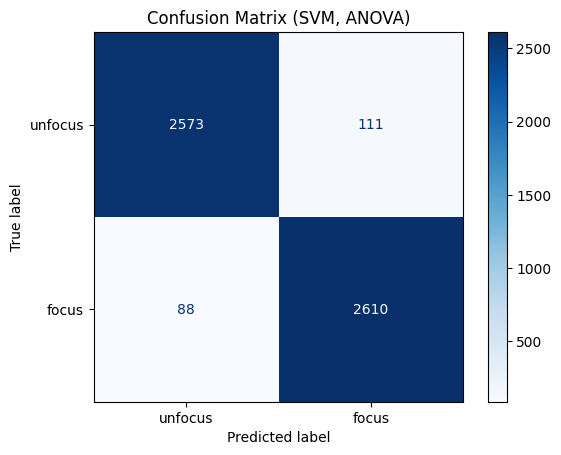

In [76]:
conf_matrix_SVM_anova = confusion_matrix(y_test, y_pred_SVM_anova)
dist = ConfusionMatrixDisplay(conf_matrix_SVM_anova, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (SVM, ANOVA)')
plt.show()

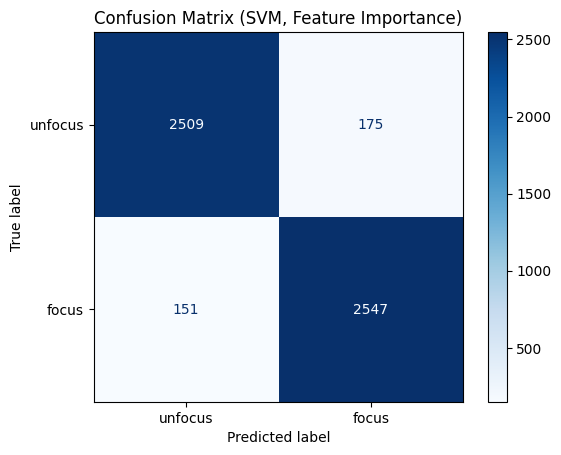

In [77]:
conf_matrix_SVM_fi = confusion_matrix(y_test, y_pred_SVM_fi)
dist = ConfusionMatrixDisplay(conf_matrix_SVM_fi, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (SVM, Feature Importance)')
plt.show()

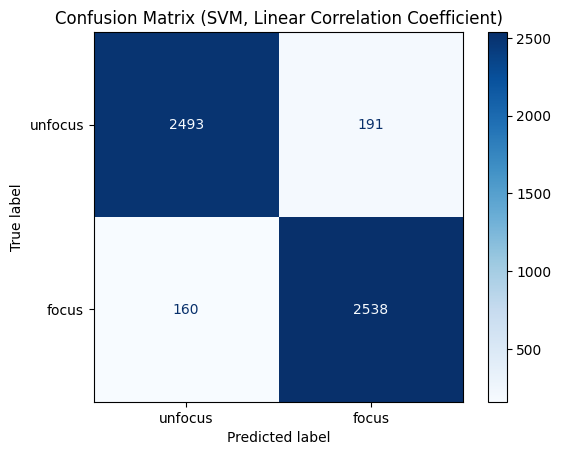

In [78]:
conf_matrix_SVM_lcc = confusion_matrix(y_test, y_pred_SVM_lcc)
dist = ConfusionMatrixDisplay(conf_matrix_SVM_lcc, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (SVM, Linear Correlation Coefficient)')
plt.show()

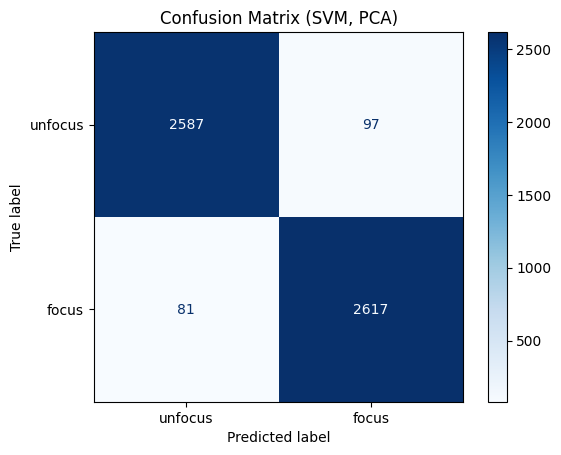

In [79]:
conf_matrix_SVM_pca = confusion_matrix(y_test, y_pred_SVM_pca)
dist = ConfusionMatrixDisplay(conf_matrix_SVM_pca, display_labels=['unfocus', 'focus'])
dist.plot(cmap='Blues')
plt.title('Confusion Matrix (SVM, PCA)')
plt.show()

### Save classical-model ROC artifacts


In [80]:
import os

os.makedirs('./artifacts/reproductions/upstream_pipeline/results/roc_artifacts', exist_ok=True)

def save_roc_artifact(name, fpr, tpr, roc_auc):
    path = f'./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/{name}.npz'
    np.savez_compressed(path, fpr=fpr, tpr=tpr, roc_auc=roc_auc)
    print(f'Saved {path}')

for suffix in ['', '_anova', '_fi', '_lcc', '_pca']:
    for model_key in ['DT', 'RF', 'KNN', 'LR', 'SVM']:
        save_roc_artifact(
            f'{model_key}{suffix}',
            globals()[f'fpr_{model_key}{suffix}'],
            globals()[f'tpr_{model_key}{suffix}'],
            globals()[f'roc_auc_{model_key}{suffix}'],
        )


Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/DT.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/RF.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/KNN.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/LR.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/SVM.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/DT_anova.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/RF_anova.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/KNN_anova.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/LR_anova.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/SVM_anova.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/DT_fi.npz
Saved ./artifacts/reproductions/upstream_pipeline/results/roc_artifacts/RF_fi.npz
Saved ./arti

### Train deep models in isolated processes


In [81]:
import subprocess
import sys
from pathlib import Path

# Keep sys.executable when this Jupyter kernel already has torch/torchvision.
# Otherwise replace it with the full path returned by: where python
# Example: DEEP_PYTHON = r'C:\Users\name\miniconda3\envs\eeg\python.exe'
DEEP_PYTHON = sys.executable
PROJECT_DIR = Path.cwd().resolve()

print(f'Notebook Python: {sys.executable}', flush=True)
print(f'Deep-training Python: {DEEP_PYTHON}', flush=True)

cmd = [
    DEEP_PYTHON,
    '-u',
    str(PROJECT_DIR / 'scripts' / 'legacy' / 'run_deep_workers.py'),
    '--epochs', '50',
    '--batch-size', '32',
    '--cache-dir', str(PROJECT_DIR / 'artifacts' / 'reproductions' / 'upstream_pipeline' / 'feature_cache'),
    '--skip-existing',
]

# Read the child process line by line so VS Code/Jupyter shows live progress.
process = subprocess.Popen(
    cmd,
    cwd=PROJECT_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding='utf-8',
    errors='replace',
    bufsize=1,
)
for line in iter(process.stdout.readline, ''):
    print(line, end='', flush=True)
process.stdout.close()
return_code = process.wait()
if return_code != 0:
    raise subprocess.CalledProcessError(return_code, cmd)


Notebook Python: c:\Users\13313\.conda\envs\EEGpy\python.exe
Deep-training Python: c:\Users\13313\.conda\envs\EEGpy\python.exe
Python executable: c:\Users\13313\.conda\envs\EEGpy\python.exe
Project directory: C:\CHLight\0-Plan\EEGreproduction\EEGAttention
torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
CUDA available: True

Running resnet18:full
Skip existing: resnet18 full

Running googlenet:full
Skip existing: googlenet full

Running resnet18:anova
Skip existing: resnet18 anova

Running googlenet:anova
Skip existing: googlenet anova

Running resnet18:fi
Skip existing: resnet18 fi

Running googlenet:fi
Skip existing: googlenet fi

Running resnet18:lcc
Skip existing: resnet18 lcc

Running googlenet:lcc
Skip existing: googlenet lcc

Running resnet18:pca
Skip existing: resnet18 pca

Running googlenet:pca
Skip existing: googlenet pca


### Draw and save ROC images from artifacts


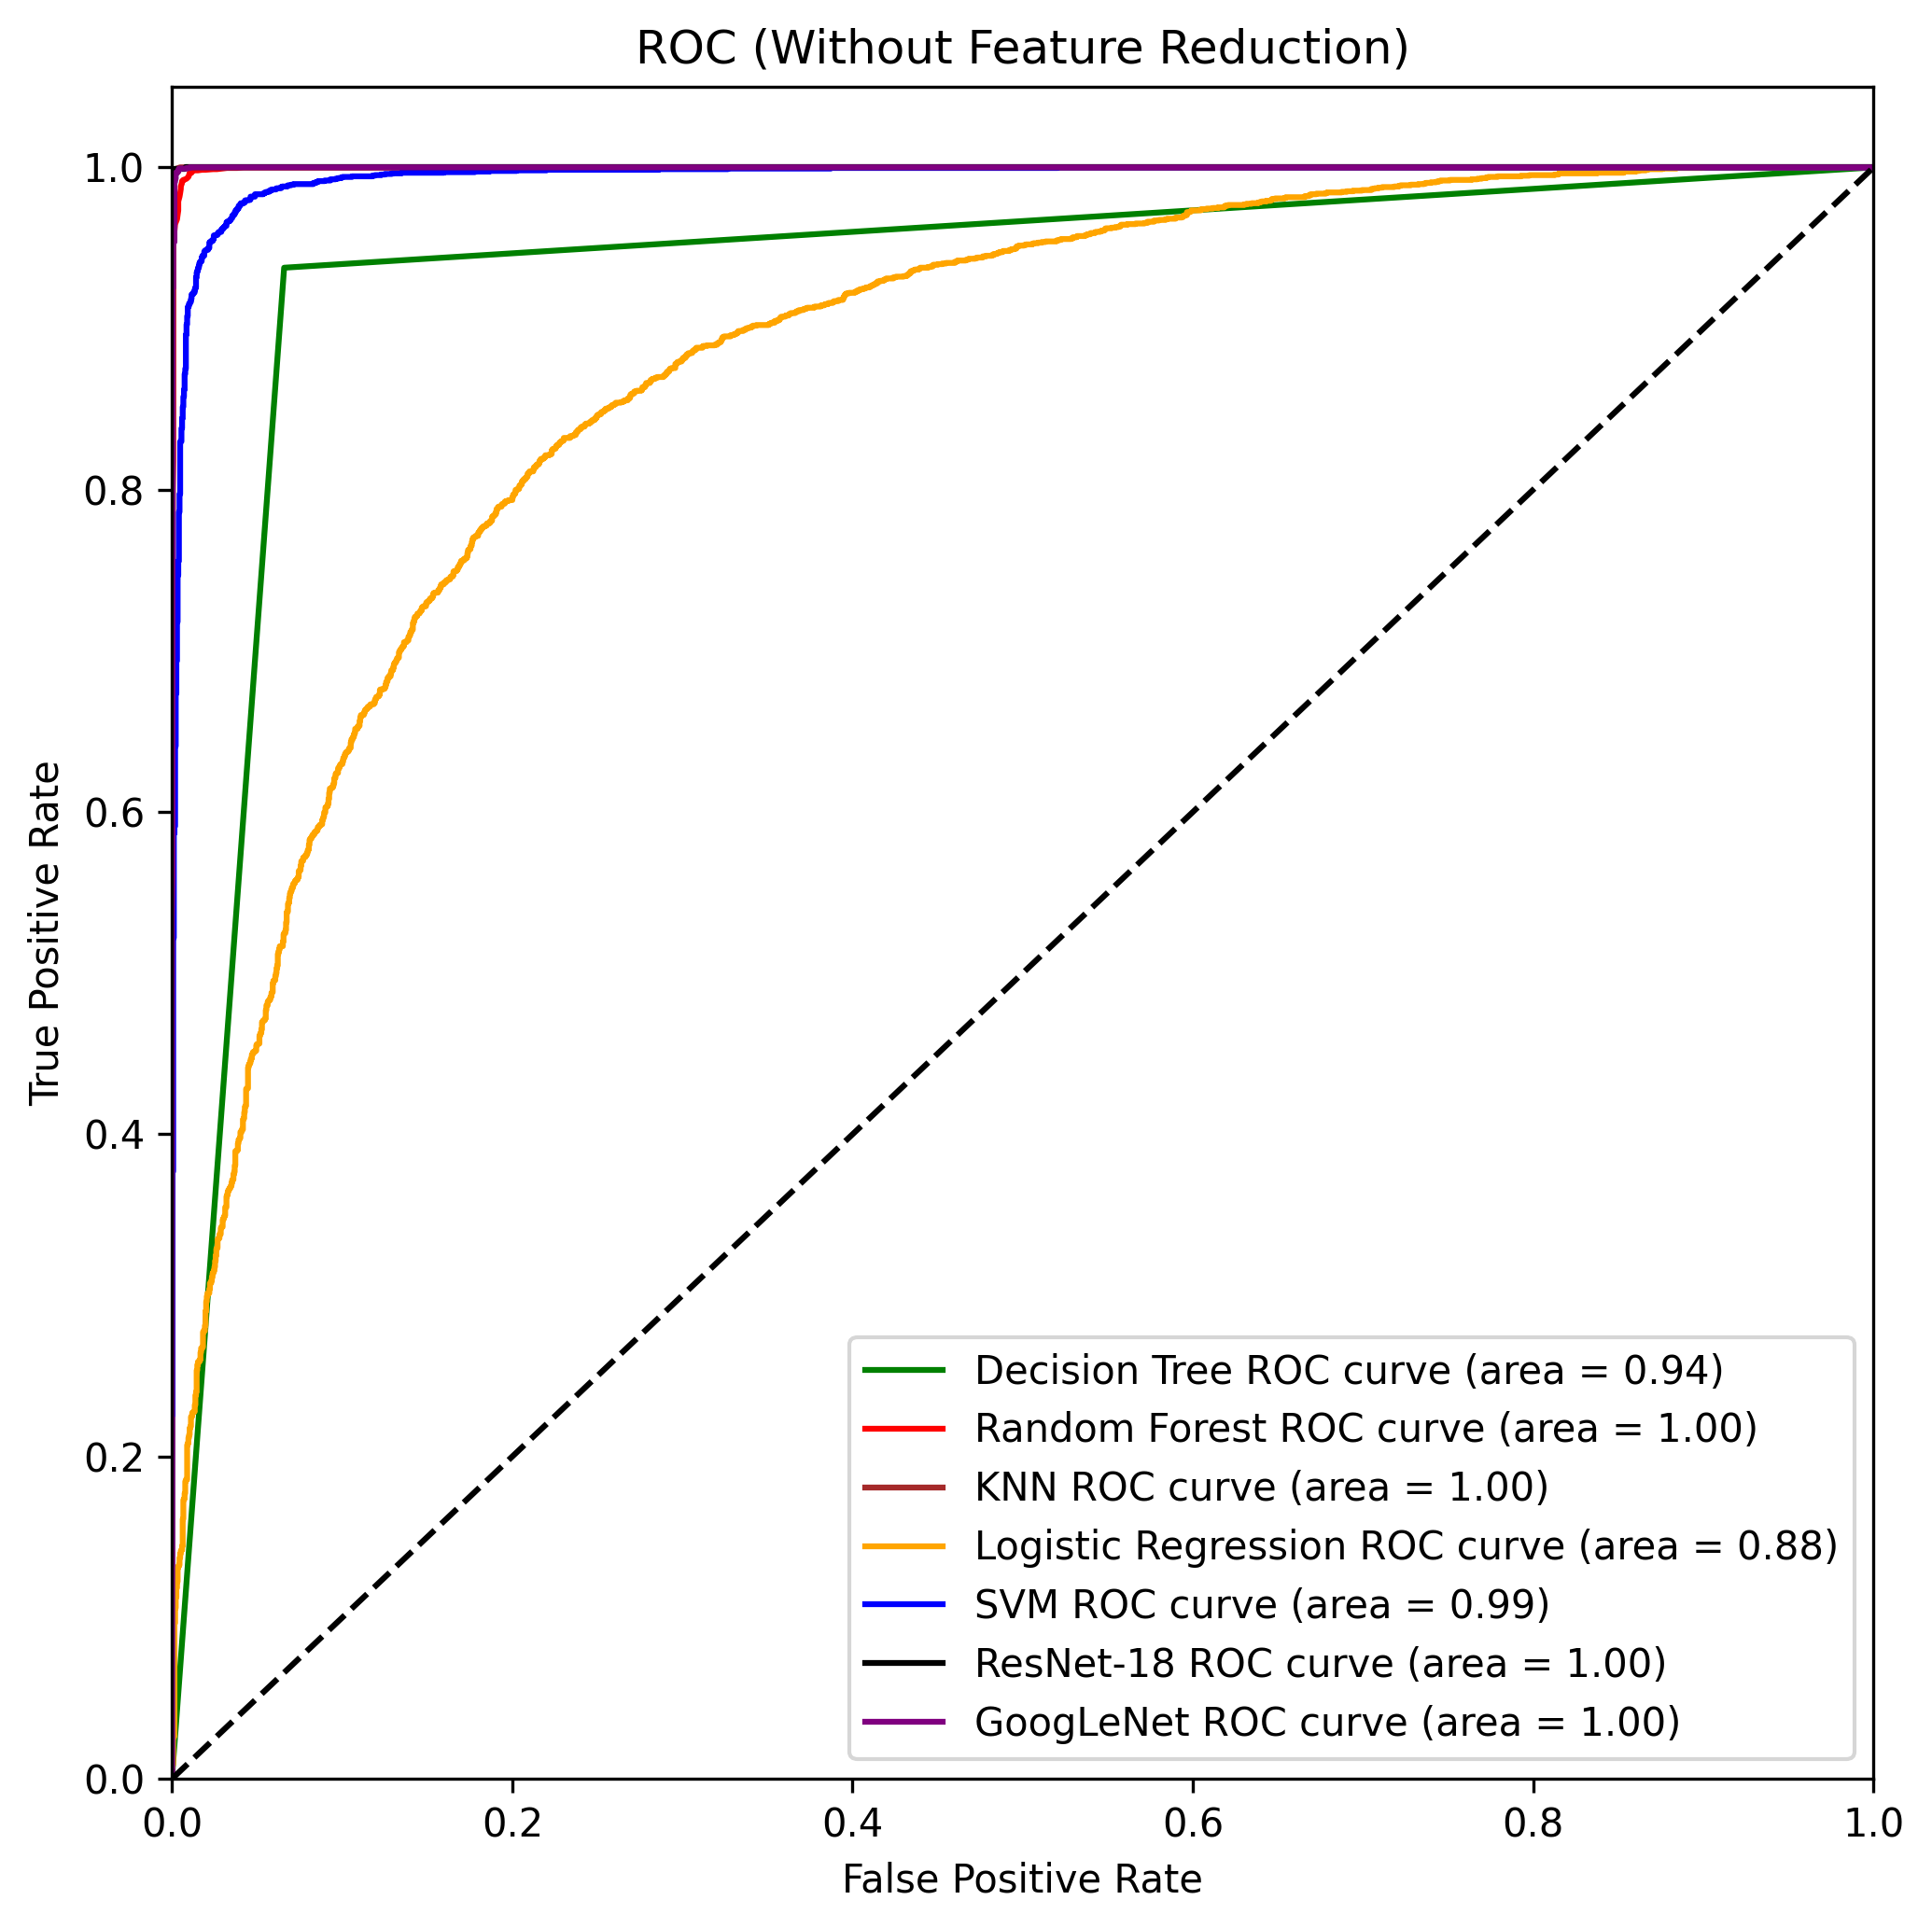

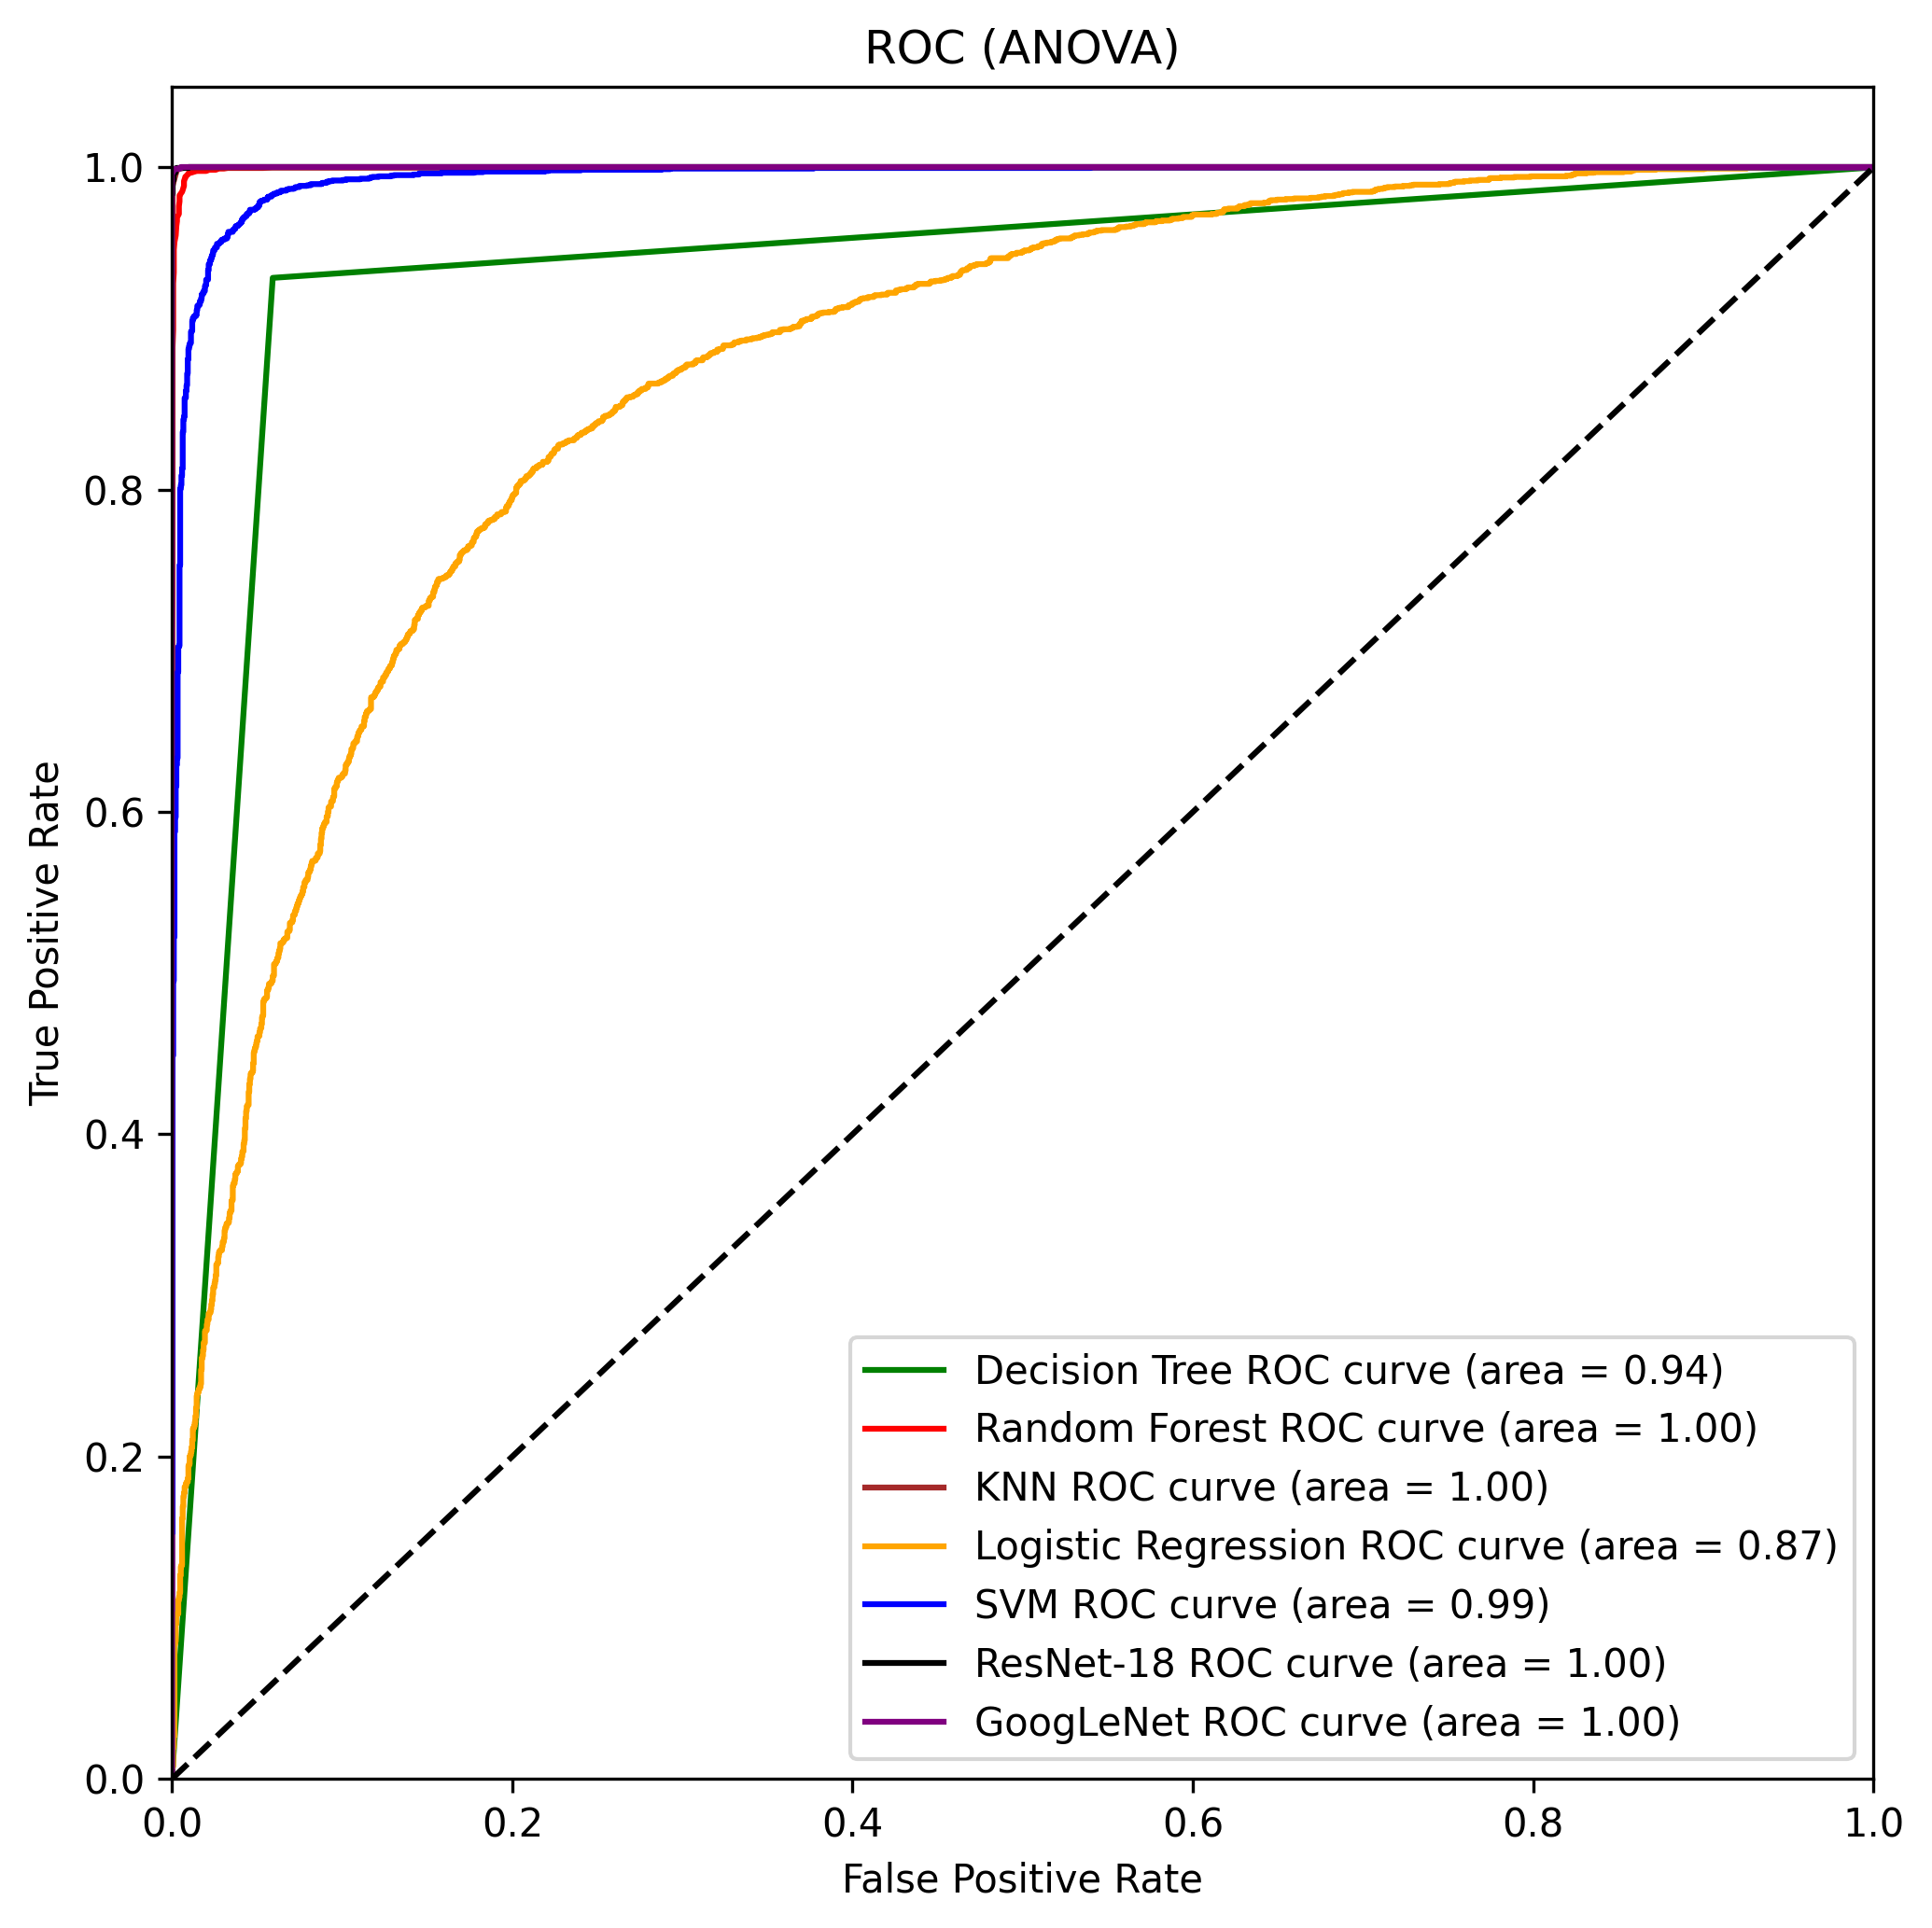

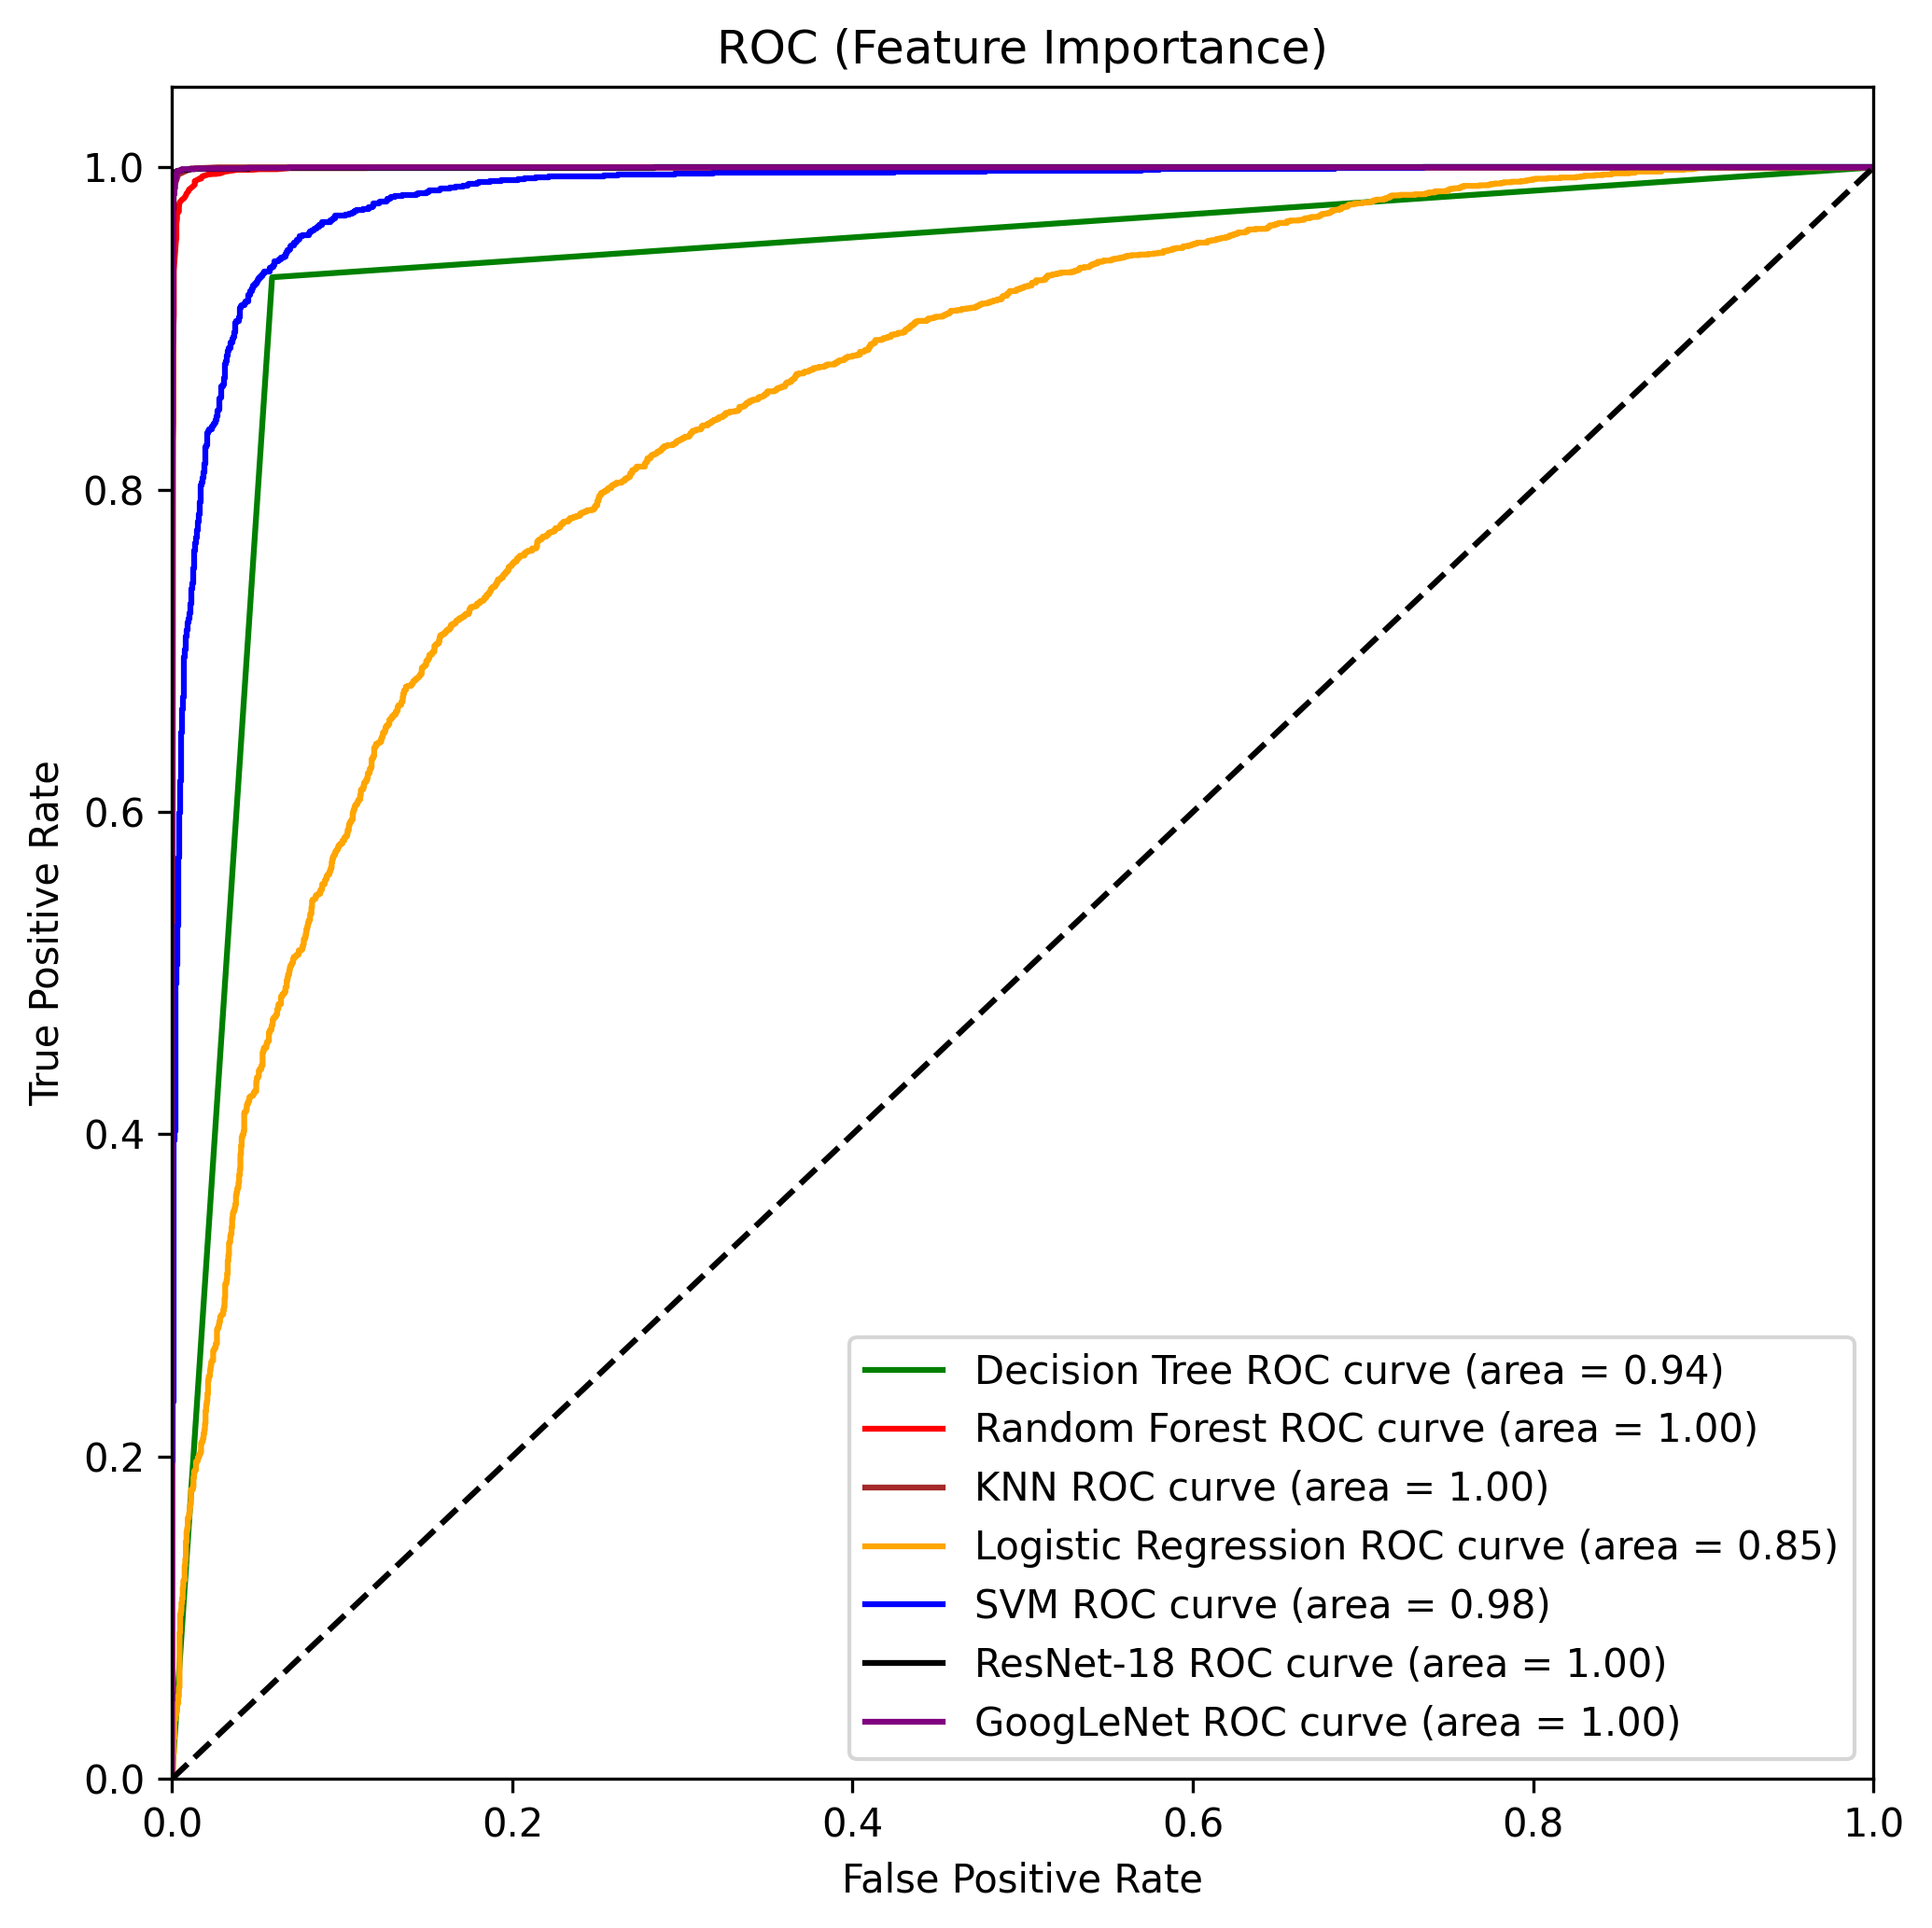

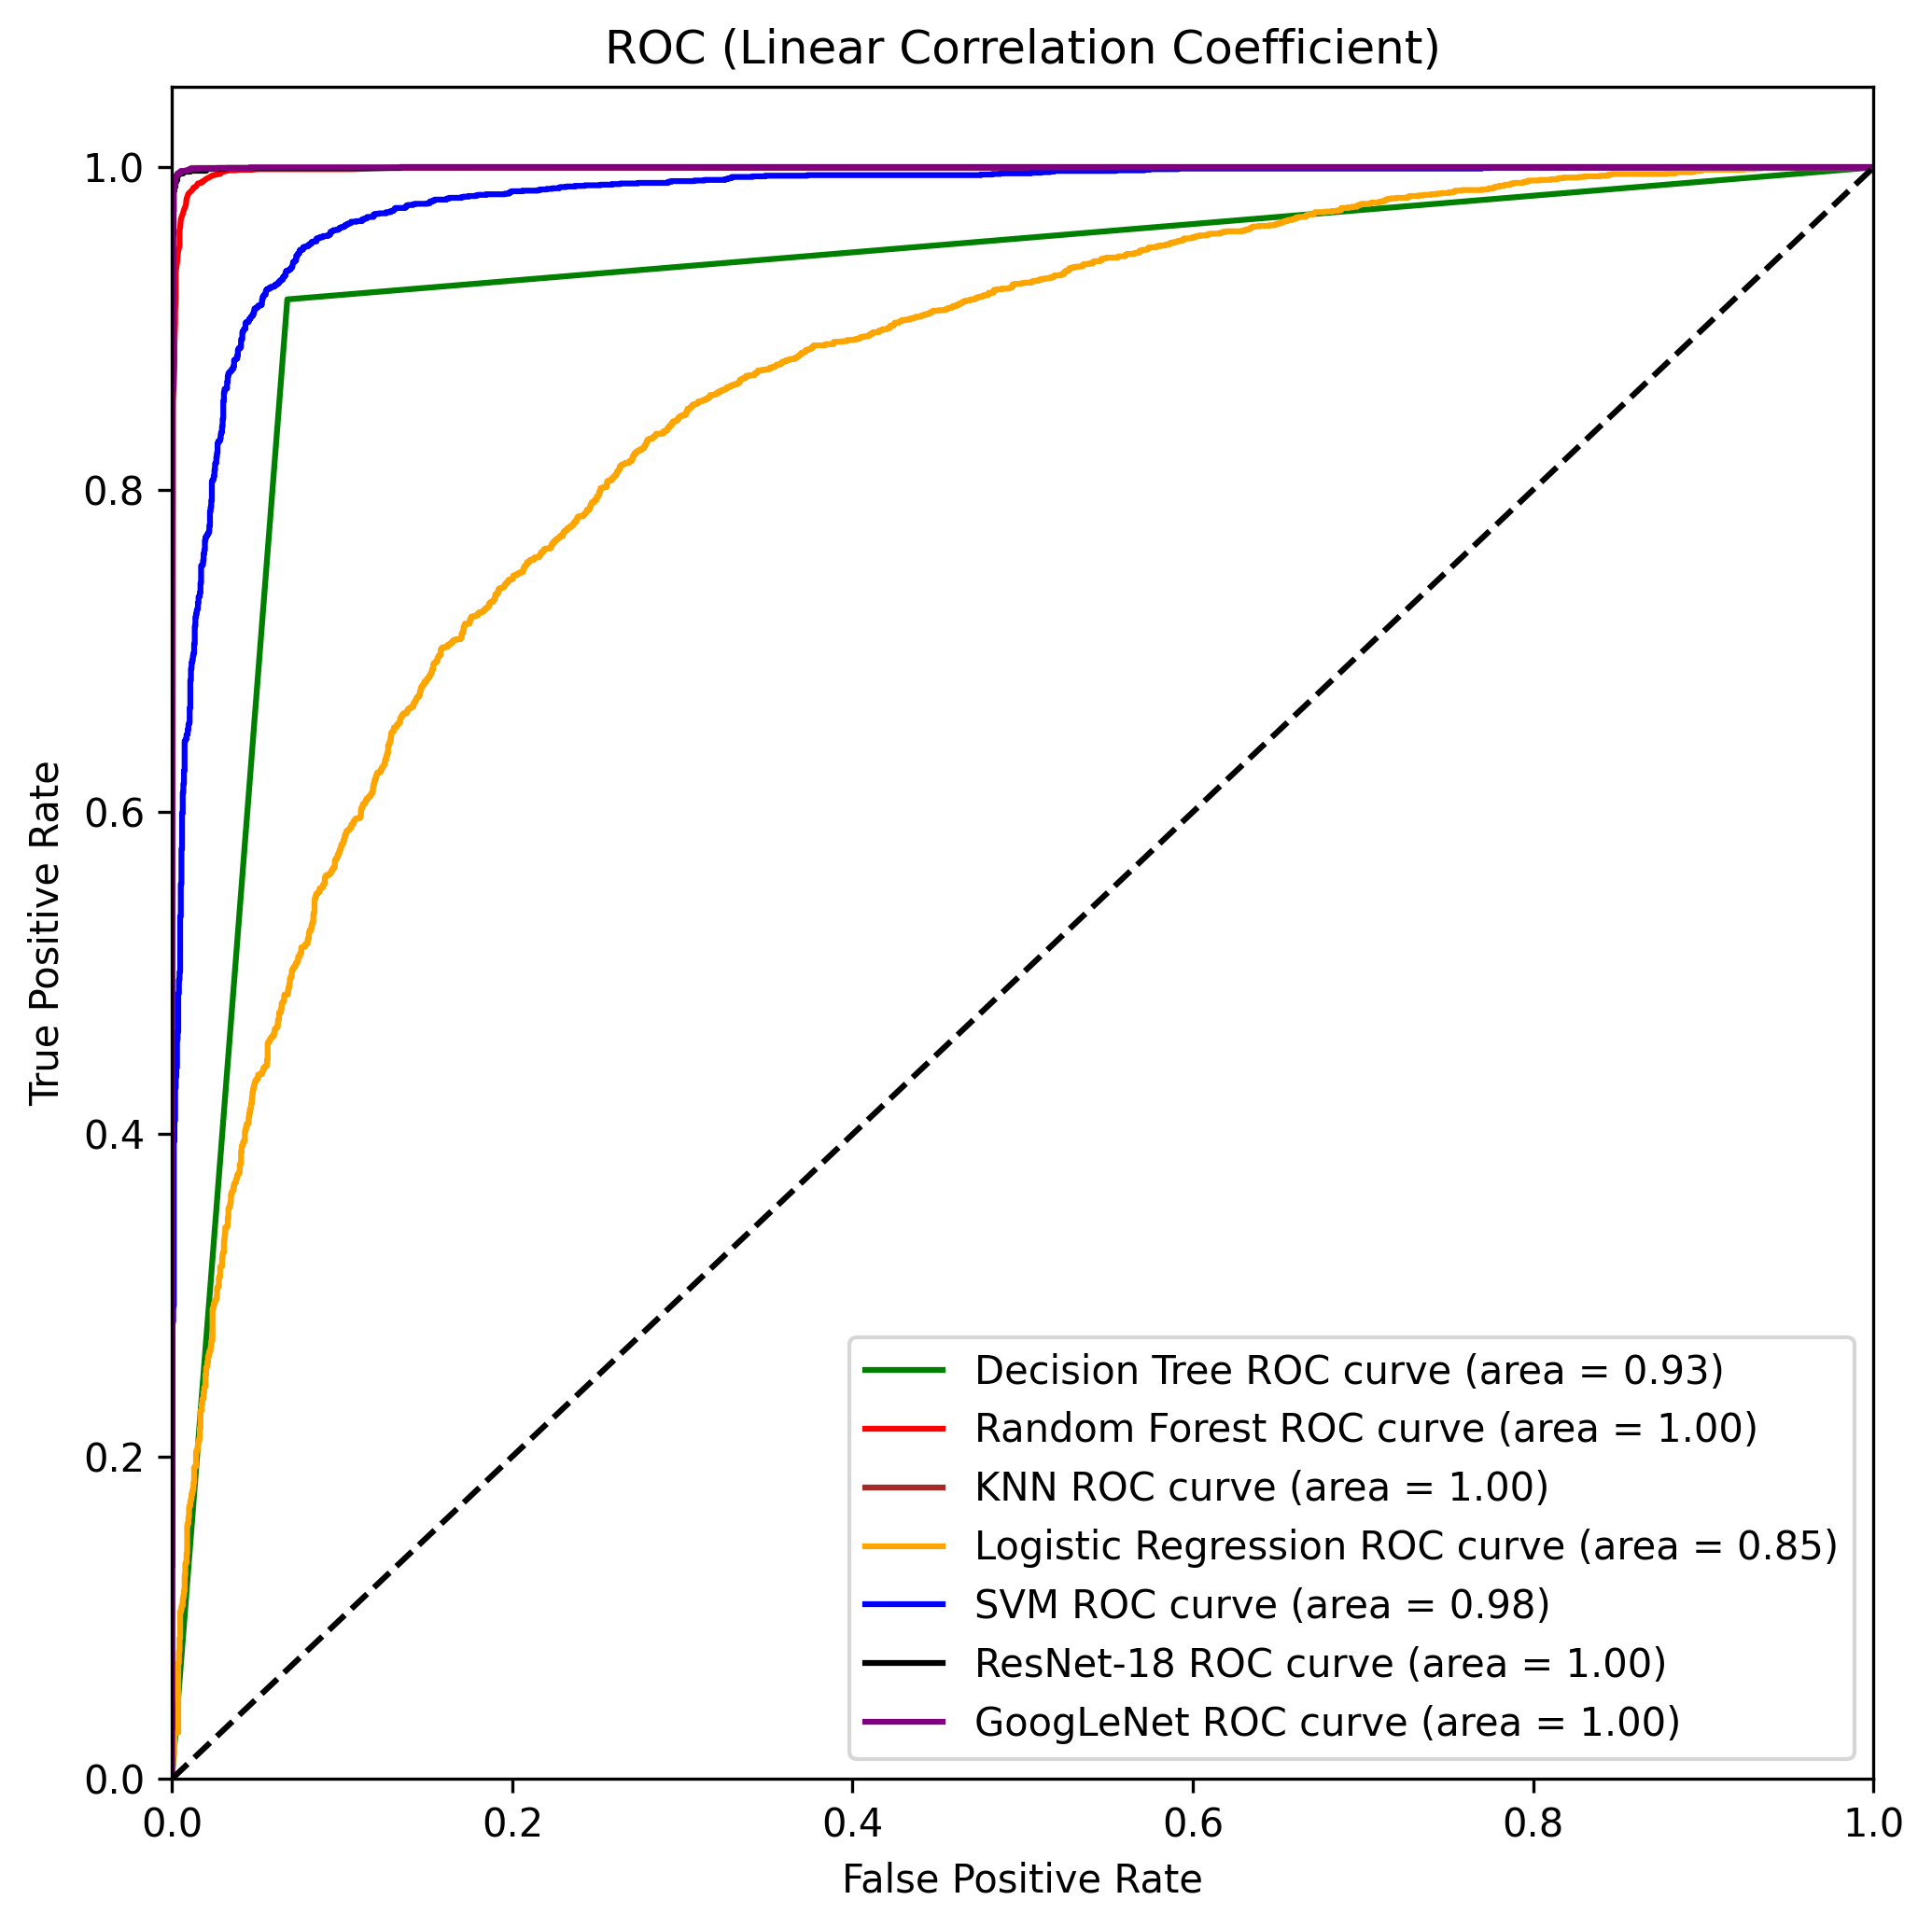

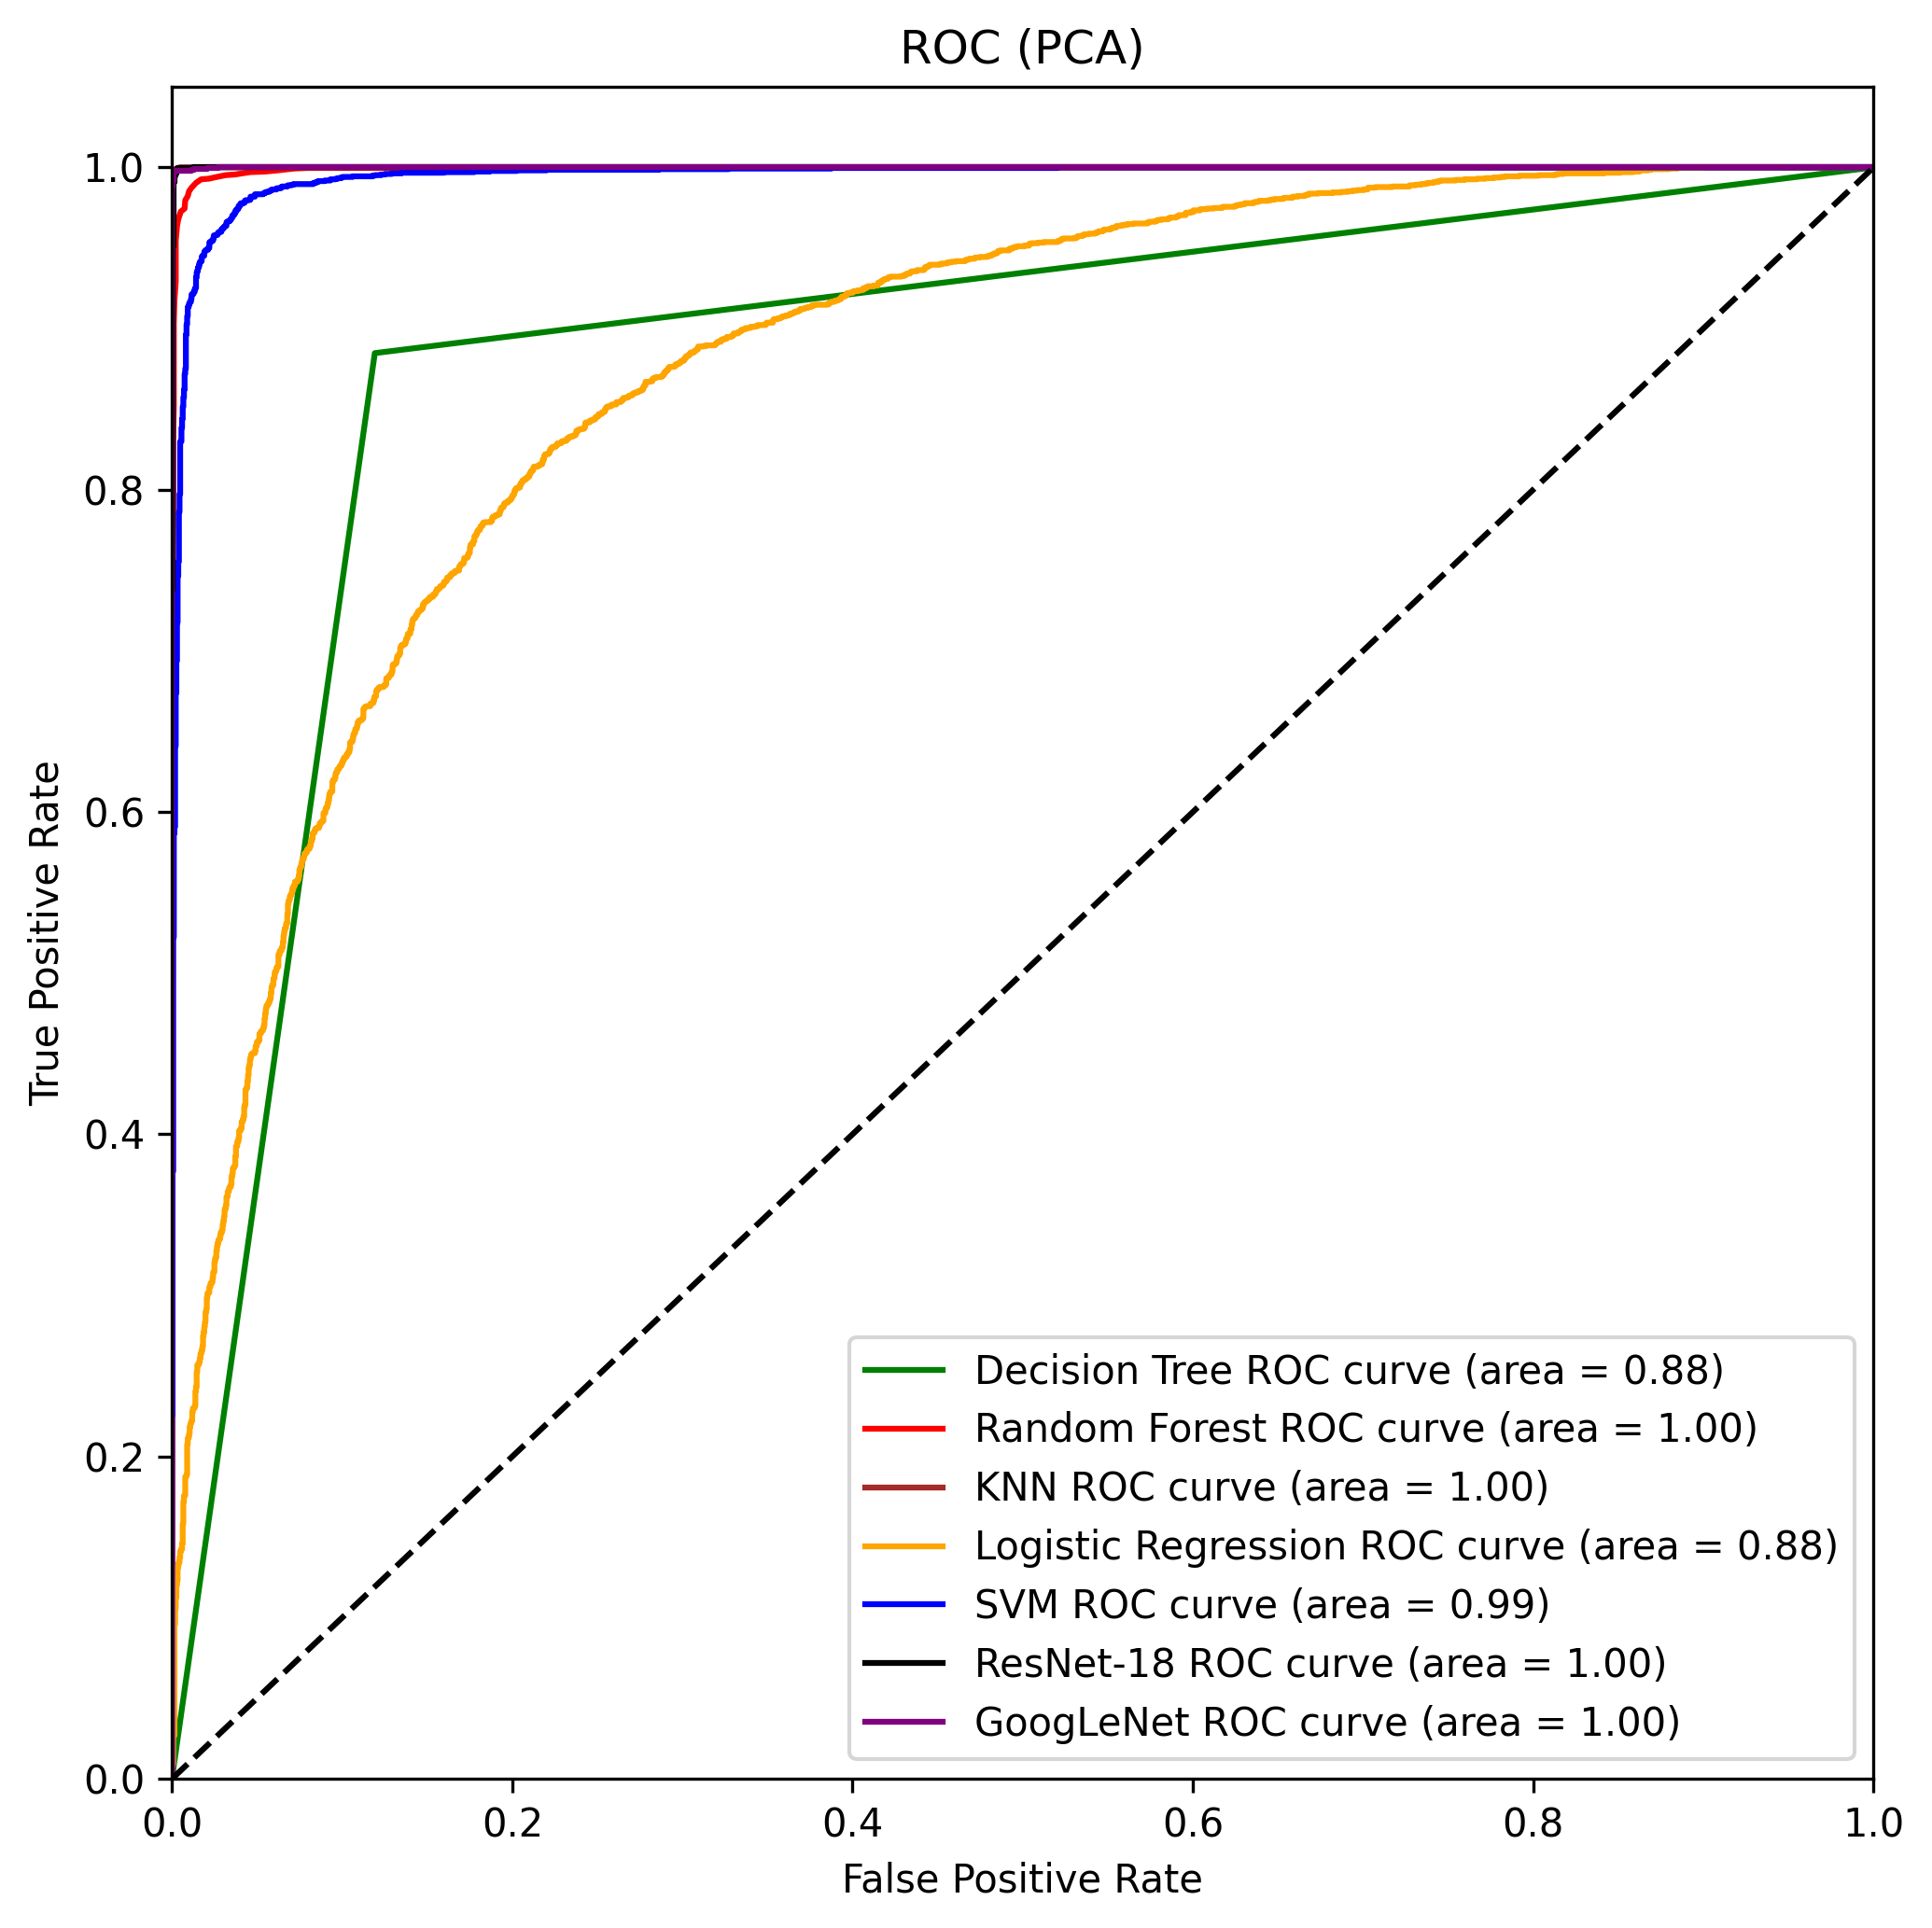

In [82]:
import subprocess
import sys
from IPython.display import Image, display

subprocess.run([sys.executable, 'save_roc_figures.py'], check=True)

for image_path in [
    './artifacts/reproductions/upstream_pipeline/results/roc_without_feature_reduction.png',
    './artifacts/reproductions/upstream_pipeline/results/roc_anova.png',
    './artifacts/reproductions/upstream_pipeline/results/roc_feature_importance.png',
    './artifacts/reproductions/upstream_pipeline/results/roc_lcc.png',
    './artifacts/reproductions/upstream_pipeline/results/roc_pca.png',
]:
    display(Image(filename=image_path))


In [83]:
result_group = pd.DataFrame(columns=['model', 'time', 'precision', 'recall', 'f1', 'test_acc'])
result_group.loc[0] = ['Decision Tree', training_time_DT, precision_DT, recall_DT, f1_DT, acc_DT]
result_group.loc[1] = ['Random Forest', training_time_RF, precision_RF, recall_RF, f1_RF, acc_RF]
result_group.loc[2] = ['KNN', training_time_KNN, precision_KNN, recall_KNN, f1_KNN, acc_KNN]
result_group.loc[3] = ['Logistic Regression', training_time_LR, precision_LR, recall_LR, f1_LR, acc_LR]
result_group.loc[4] = ['SVM', training_time_SVM, precision_SVM, recall_SVM, f1_SVM, acc_SVM]

In [84]:
result_group_anova = pd.DataFrame(columns=['model', 'time', 'precision', 'recall', 'f1', 'test_acc'])
result_group_anova.loc[0] = ['Decision Tree', training_time_DT_anova, precision_DT_anova, recall_DT_anova, f1_DT_anova, acc_DT_anova]
result_group_anova.loc[1] = ['Random Forest', training_time_RF_anova, precision_RF_anova, recall_RF_anova, f1_RF_anova, acc_RF_anova]
result_group_anova.loc[2] = ['KNN', training_time_KNN_anova, precision_KNN_anova, recall_KNN_anova, f1_KNN_anova, acc_KNN_anova]
result_group_anova.loc[3] = ['Logistic Regression', training_time_LR_anova, precision_LR_anova, recall_LR_anova, f1_LR_anova, acc_LR_anova]
result_group_anova.loc[4] = ['SVM', training_time_SVM_anova, precision_SVM_anova, recall_SVM_anova, f1_SVM_anova, acc_SVM_anova]

In [85]:
result_group_fi = pd.DataFrame(columns=['model', 'time', 'precision', 'recall', 'f1', 'test_acc'])
result_group_fi.loc[0] = ['Decision Tree', training_time_DT_fi, precision_DT_fi, recall_DT_fi, f1_DT_fi, acc_DT_fi]
result_group_fi.loc[1] = ['Random Forest', training_time_RF_fi, precision_RF_fi, recall_RF_fi, f1_RF_fi, acc_RF_fi]
result_group_fi.loc[2] = ['KNN', training_time_KNN_fi, precision_KNN_fi, recall_KNN_fi, f1_KNN_fi, acc_KNN_fi]
result_group_fi.loc[3] = ['Logistic Regression', training_time_LR_fi, precision_LR_fi, recall_LR_fi, f1_LR_fi, acc_LR_fi]
result_group_fi.loc[4] = ['SVM', training_time_SVM_fi, precision_SVM_fi, recall_SVM_fi, f1_SVM_fi, acc_SVM_fi]

In [86]:
result_group_lcc = pd.DataFrame(columns=['model', 'time', 'precision', 'recall', 'f1', 'test_acc'])
result_group_lcc.loc[0] = ['Decision Tree', training_time_DT_lcc, precision_DT_lcc, recall_DT_lcc, f1_DT_lcc, acc_DT_lcc]
result_group_lcc.loc[1] = ['Random Forest', training_time_RF_lcc, precision_RF_lcc, recall_RF_lcc, f1_RF_lcc, acc_RF_lcc]
result_group_lcc.loc[2] = ['KNN', training_time_KNN_lcc, precision_KNN_lcc, recall_KNN_lcc, f1_KNN_lcc, acc_KNN_lcc]
result_group_lcc.loc[3] = ['Logistic Regression', training_time_LR_lcc, precision_LR_lcc, recall_LR_lcc, f1_LR_lcc, acc_LR_lcc]
result_group_lcc.loc[4] = ['SVM', training_time_SVM_lcc, precision_SVM_lcc, recall_SVM_lcc, f1_SVM_lcc, acc_SVM_lcc]

In [87]:
result_group_pca = pd.DataFrame(columns=['model', 'time', 'precision', 'recall', 'f1', 'test_acc'])
result_group_pca.loc[0] = ['Decision Tree', training_time_DT_pca, precision_DT_pca, recall_DT_pca, f1_DT_pca, acc_DT_pca]
result_group_pca.loc[1] = ['Random Forest', training_time_RF_pca, precision_RF_pca, recall_RF_pca, f1_RF_pca, acc_RF_pca]
result_group_pca.loc[2] = ['KNN', training_time_KNN_pca, precision_KNN_pca, recall_KNN_pca, f1_KNN_pca, acc_KNN_pca]
result_group_pca.loc[3] = ['Logistic Regression', training_time_LR_pca, precision_LR_pca, recall_LR_pca, f1_LR_pca, acc_LR_pca]
result_group_pca.loc[5] = ['SVM', training_time_SVM_pca, precision_SVM_pca, recall_SVM_pca, f1_SVM_pca, acc_SVM_pca]

In [88]:
result_group.to_excel('./artifacts/reproductions/upstream_pipeline/results/train_info_group_part_detrend_plr_stft_bin_win.xlsx', index=False)
result_group_anova.to_excel('./artifacts/reproductions/upstream_pipeline/results/train_info_group_part_detrend_plr_stft_bin_win_anova.xlsx', index=False)
result_group_fi.to_excel('./artifacts/reproductions/upstream_pipeline/results/train_info_group_part_detrend_plr_stft_bin_win_fi.xlsx', index=False)
result_group_lcc.to_excel('./artifacts/reproductions/upstream_pipeline/results/train_info_group_part_detrend_plr_stft_bin_win_lcc.xlsx', index=False)
result_group_pca.to_excel('./artifacts/reproductions/upstream_pipeline/results/train_info_group_part_detrend_plr_stft_bin_win_pca.xlsx', index=False)